# Import Statements

In [66]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import pickle
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import plot_importance
from matplotlib import pyplot

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Define all functions

In [3]:
class EarlyStopping:
    def __init__(self, patience=10, delta=1e-4):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [21]:
# Build model with best hyperparameters 2 laers or 3 layer.
#def build_model(input_size, params):
    return nn.Sequential(
        nn.Linear(input_size, params['hidden_size1']),
        nn.ReLU(),
        nn.Dropout(params['dropout1']),
        nn.Linear(params['hidden_size1'], params['hidden_size2']),
        nn.ReLU(),
        nn.Dropout(params['dropout2']),
        nn.Linear(params['hidden_size2'], params['hidden_size3']),
        nn.ReLU(),
        nn.Linear(params['hidden_size3'], 1)
    )
    return nn.Sequential(*layers)
#USAGE - model = build_model(X.shape[1], params)

# Build model with best hyperparameters
#def build_model(input_size, params):
    return nn.Sequential(
        nn.Linear(input_size, params['hidden_size1']),
        nn.ReLU(),
        nn.Dropout(params['dropout1']),
        nn.Linear(params['hidden_size1'], params['hidden_size2']),
        nn.ReLU(),
        nn.Linear(params['hidden_size2'], 1)
    )
    return nn.Sequential(*layers)

IndentationError: unexpected indent (2407977649.py, line 3)

In [4]:
def build_model(input_size, params):
    layers = []
    layers.append(nn.Linear(input_size, params['hidden_size1']))
    layers.append(nn.ReLU())
    layers.append(nn.Dropout(params['dropout1']))

    if params['n_layers'] > 1:
        layers.append(nn.Linear(params['hidden_size1'], params['hidden_size2']))
        layers.append(nn.ReLU())
        # Only add dropout2 if n_layers > 2
        if params['n_layers'] > 2:
            layers.append(nn.Dropout(params['dropout2']))

    if params['n_layers'] > 2:
        layers.append(nn.Linear(params['hidden_size2'], params['hidden_size3']))
        layers.append(nn.ReLU())

    # Output layer
    last_hidden = f"hidden_size{params['n_layers']}"
    layers.append(nn.Linear(params[last_hidden], 1))

    return nn.Sequential(*layers)

In [5]:
def objective(trial):
    #Hyperparametr space
    params = {
            'hidden_size1': trial.suggest_categorical('hidden_size1', [100, 200, 300]),
            #'hidden_size1': trial.suggest_int('hidden_size1', 64, 256, step=32),
            #'hidden_size2': trial.suggest_int('hidden_size2', 32, 128, step=16),
            #'hidden_size3': trial.suggest_int('hidden_size3', 32, 128, step=16),
            'dropout1': trial.suggest_float('dropout1', 0.01, 0.1),
            #'dropout2': trial.suggest_float('dropout2', 0.01, 0.1),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128]),
            'optimizer': trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD']),
            #'num_epochs': trial.suggest_categorical('num_epochs', [30, 50, 70]),
            #'patience': trial.suggest_int('patience', 5, 15),
            'num_epochs': 100,
            'patience': 10,
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
            'n_layers': trial.suggest_int('n_layers', 1, 3)
        }

        # Only sample hidden_size2 if n_layers > 1
    if params['n_layers'] > 1:
        params['hidden_size2'] = trial.suggest_categorical('hidden_size2', [50, 100, 150])
    else:
        params['hidden_size2'] = None
    
    # Only sample hidden_size3 and dropout2 if n_layers > 2
    if params['n_layers'] > 2:
        params['hidden_size3'] = trial.suggest_categorical('hidden_size3', [25, 50, 75])
        params['dropout2'] = trial.suggest_float('dropout2', 0.01, 0.1)
    else:
        params['hidden_size3'] = None
        params['dropout2'] = None
        
    # Build model
    model = build_model(X_train.shape[1], params).to(device)
    optimizer = getattr(optim, params['optimizer'])(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=params['patience'])

    # Prepare data
    #X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    #y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    #X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    #y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)

    val_losses = []

    for epoch in range(params['num_epochs']):
        # Training
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = loss_function(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validation (after each epoch)
        model.eval()
        with torch.no_grad():
            preds = model(X_val).cpu().numpy()
            true = y_val.cpu().numpy()
            val_loss = loss_function(torch.tensor(preds), y_val.cpu())
            val_losses.append(val_loss.item())

        avg_val_loss = np.mean(val_losses[-5:])  # average of last 5 epochs for stability
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    mse = mean_squared_error(true, preds)
    return mse  # Optuna tries to minimize this value



In [6]:
def complete_params(params):
    params = dict(params) 
    params.setdefault('num_epochs', 100)
    params.setdefault('patience', 10)
    return params

In [7]:
def cross_validate(X, y, best_params, n_splits, checkpoint_path='best_model_checkpoint.pth'):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_losses = []
    best_model_weights = None
    best_loss = float('inf')
    fold = 1

    for train, test in kf.split(X, y):
        print(f"Training fold {fold}")

        model = build_model(X.shape[1], best_params).to(device)
        lr = best_params.get('lr', 0.001)
        opt_name = best_params.get('optimizer', 'Adam')

        if opt_name == 'Adam':
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=best_params.get('weight_decay', 0.0))
        elif opt_name == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=best_params.get('weight_decay', 0.0))
        elif opt_name == 'RMSprop':
            optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=best_params.get('weight_decay', 0.0))
        else:
            raise ValueError(f"Unsupported optimizer: {opt_name}")

        loss_fn = nn.MSELoss()
        patience = best_params.get('patience', 10)
        early_stopping_counter = 0
        best_val_loss = float('inf')

        train_dataset = torch.utils.data.TensorDataset(X[train], y[train])
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)

        # Validation data for this fold
        X_val = X[test].to(device)
        y_val = y[test].to(device)

        for epoch in range(best_params['num_epochs']):
            model.train()
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = loss_fn(outputs, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            model.eval()
            with torch.no_grad():
                val_output = model(X_val)
                val_loss = loss_fn(val_output, y_val)
                val_loss_value = val_loss.item()
                #print(f"Fold {fold} Epoch {epoch+1} validation loss: {val_loss_value:.4f}")

                if val_loss_value < best_val_loss - 1e-6:
                    best_val_loss = val_loss_value
                    early_stopping_counter = 0
                    # Save the best model weights for this fold
                    best_fold_weights = model.state_dict()
                else:
                    early_stopping_counter += 1

                if early_stopping_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1} for fold {fold}")
                    break
                
        print(f"Fold {fold} validation loss: {best_val_loss:.4f}")
        fold_losses.append(best_val_loss)
        # Save the best model weights across all folds
        if best_val_loss < best_loss:
            best_loss = best_val_loss
            best_model_weights = best_fold_weights

        fold += 1

    average_val_loss = np.mean(fold_losses)
    print(f"\nAverage validation loss across all folds: {average_val_loss:.4f}")

    final_model = build_model(X.shape[1], best_params)
    final_model.load_state_dict(best_model_weights)

    checkpoint = {
        'model_state_dict': final_model.state_dict(),
        'best_params': best_params,
        'input_dim': X.shape[1]
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint saved as '{checkpoint_path}'.")

    return final_model, average_val_loss


In [8]:
# Evaluation
def evaluate_on_holdout(X_holdout, y_holdout, best_model):
    # Prepare the data
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_holdout_tensor = torch.tensor(X_holdout, dtype=torch.float32).to(device)
    y_holdout_tensor = torch.tensor(y_holdout, dtype=torch.float32).view(-1, 1).to(device)
    
    best_model = best_model.to(device)
    best_model.eval()
    with torch.no_grad():
        predictions = best_model(X_holdout_tensor)

    loss_function = nn.MSELoss()
    holdout_loss = loss_function(predictions, y_holdout_tensor)
    
    y_true_np = y_holdout_tensor.cpu().numpy()
    y_pred_np = predictions.cpu().numpy()

    mse = mean_squared_error(y_true_np, y_pred_np)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true_np, y_pred_np)
    r2 = r2_score(y_true_np, y_pred_np)
    
    metrics = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Holdout_Loss": holdout_loss.item()
    }
    
    print("\nEvaluation Metrics on Holdout Set:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")
    
    return predictions, metrics

# HOW TO USE - predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_model)

# PCA 

In [243]:
pca_full_train = pd.read_pickle("pickle_files/pca_full_training_md.pkl")

In [244]:
pca_full_train = pca_full_train.reset_index().set_index('Line')
pca_full_train = pca_full_train.drop(['index','new_line'], axis=1)
pca_full_train.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,43.9333,5.33333,1,0,0,0,0,0,1,113.0
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,83.2000,1.40000,0,0,1,0,0,1,0,107.0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,60.8000,3.80000,0,0,1,0,0,1,0,100.0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,67.0000,0.80000,0,1,0,0,0,1,0,103.0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,79.0000,1.00000,0,1,0,0,0,1,0,103.0


## PC200

### All covariates

In [245]:
X_all = pd.concat([pca_full_train.iloc[:, :200], pca_full_train.iloc[:, -12:]], axis=1)
X_all = X_all.drop(['MD'], axis=1)
X_all.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [246]:
X_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s503 to s2236
Columns: 211 entries, 1 to landrace
dtypes: float64(204), int64(7)
memory usage: 4.0+ MB


In [247]:
X_dupe = pd.concat([pca_full_train.iloc[:, :200], pca_full_train.iloc[:, -12:]], axis=1)
X_dupe = X_dupe.drop(['MD'], axis=1)
X_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [248]:
y_all = pca_full_train.iloc[:, 511:]
y_all.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [249]:
X_tensor = torch.tensor(X_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [250]:
#X_all = X_all.to_numpy()
#y_all = y_all.to_numpy()
#X_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)
#y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [251]:
print(X_tensor.shape)

torch.Size([2450, 211])


In [252]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [253]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 11:59:30,924] A new study created in memory with name: no-name-18ca2a54-9de5-4232-a503-21bc5d41f8c0
[I 2025-05-26 11:59:32,246] Trial 0 finished with value: 102.34354400634766 and parameters: {'hidden_size1': 200, 'hidden_size2': 75, 'hidden_size3': 50, 'dropout1': 0.014231147006390152, 'dropout2': 0.08817247993290127, 'lr': 0.009843733684713654, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 7, 'n_layers': 3}. Best is trial 0 with value: 102.34354400634766.


Early stopping at epoch 26


[I 2025-05-26 11:59:34,726] Trial 1 finished with value: 998.2146606445312 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.023663061224120315, 'dropout2': 0.08008901236439443, 'lr': 0.0009388404634379951, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 9, 'n_layers': 1}. Best is trial 0 with value: 102.34354400634766.
[I 2025-05-26 11:59:38,339] Trial 2 finished with value: 8754.5224609375 and parameters: {'hidden_size1': 75, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.08173978719254062, 'dropout2': 0.09569445462703818, 'lr': 0.00018422681997889032, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 13, 'n_layers': 2}. Best is trial 0 with value: 102.34354400634766.
[I 2025-05-26 11:59:40,154] Trial 3 finished with value: 9655.4169921875 and parameters: {'hidden_size1': 75, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.012842958187567723, 'dropout2': 0.028091307009484638, 'lr': 0.000189

Early stopping at epoch 11


[I 2025-05-26 11:59:54,136] Trial 11 finished with value: 139.58692932128906 and parameters: {'hidden_size1': 75, 'hidden_size2': 75, 'hidden_size3': 50, 'dropout1': 0.06494520415287335, 'dropout2': 0.07018308367942382, 'lr': 0.004275057964503554, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 11, 'n_layers': 3}. Best is trial 0 with value: 102.34354400634766.


...

Early stopping at epoch 63


[I 2025-05-26 12:01:57,925] Trial 39 finished with value: 101.10226440429688 and parameters: {'hidden_size1': 75, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout1': 0.039813157987629307, 'dropout2': 0.024215675610017053, 'lr': 0.0002651647495693566, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 13, 'n_layers': 2}. Best is trial 19 with value: 80.87623596191406.
[I 2025-05-26 12:01:59,334] Trial 40 finished with value: 11615.001953125 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.015458331894710242, 'dropout2': 0.036860971635767695, 'lr': 0.0005461037927150551, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 14, 'n_layers': 3}. Best is trial 19 with value: 80.87623596191406.
[I 2025-05-26 12:02:05,731] Trial 41 finished with value: 85.57849884033203 and parameters: {'hidden_size1': 75, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.04512140068249585, 'dropout2': 0.03343278083264037, 'lr': 

Early stopping at epoch 49


[I 2025-05-26 12:02:30,296] Trial 46 finished with value: 101.3363037109375 and parameters: {'hidden_size1': 75, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.03437582322247533, 'dropout2': 0.05518489733781615, 'lr': 0.0005986127736102604, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 14, 'n_layers': 3}. Best is trial 19 with value: 80.87623596191406.
[I 2025-05-26 12:02:32,423] Trial 47 finished with value: 107.75564575195312 and parameters: {'hidden_size1': 75, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.039838439655301996, 'dropout2': 0.037774470025783005, 'lr': 0.00042133222704126205, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 6, 'n_layers': 3}. Best is trial 19 with value: 80.87623596191406.
[I 2025-05-26 12:02:38,202] Trial 48 finished with value: 1401.4501953125 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.026160154604559213, 'dropout2': 0.046300824747899705, 'l

Best hyperparameters: {'hidden_size1': 75, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.03950572724871417, 'dropout2': 0.04836306312028614, 'lr': 0.0016419720979708582, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 15, 'n_layers': 3}


In [257]:
best_params = study.best_params

In [258]:
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_200_best_model_allfeats_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 56 for fold 1
Fold 1 validation loss: 75.3612
Training fold 2
Fold 2 validation loss: 101.5208
Training fold 3
Early stopping at epoch 52 for fold 3
Fold 3 validation loss: 96.3784
Training fold 4
Fold 4 validation loss: 77.7405
Training fold 5
Fold 5 validation loss: 96.6210
Training fold 6
Fold 6 validation loss: 93.8465
Training fold 7
Fold 7 validation loss: 80.4847
Training fold 8
Fold 8 validation loss: 108.3109
Training fold 9
Early stopping at epoch 42 for fold 9
Fold 9 validation loss: 111.9940
Training fold 10
Fold 10 validation loss: 88.0566

Average validation loss across all folds: 93.0315
Checkpoint saved as 'pca_200_best_model_allfeats_mlp_md.pth'.


In [259]:
best_mlp_model

Sequential(
  (0): Linear(in_features=211, out_features=75, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.03950572724871417, inplace=False)
  (3): Linear(in_features=75, out_features=50, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.04836306312028614, inplace=False)
  (6): Linear(in_features=50, out_features=25, bias=True)
  (7): ReLU()
  (8): Linear(in_features=25, out_features=1, bias=True)
)

In [260]:
pca_full_holdout = pd.read_pickle("pickle_files/pca_full_holdout_md.pkl")
pca_full_holdout = pca_full_holdout.reset_index().set_index('Line')
pca_full_holdout = pca_full_holdout.drop(['index','new_line'], axis=1)
pca_full_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [261]:
X_holdout = pca_full_holdout.iloc[:, :511]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [262]:
y_holdout = pca_full_holdout.iloc[:, 511:]
y_holdout.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [263]:
# Ensure both training and holdout datasets have the same columns
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [264]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s2692 to s612
Columns: 211 entries, 1 to landrace
dtypes: float64(204), int64(7)
memory usage: 1015.3+ KB


In [265]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [266]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 113.9752
RMSE: 10.6759
MAE: 8.0568
R2: 0.6634
Holdout_Loss: 113.9752


In [164]:
pickle.dump(best_mlp_model, open("pca_200_best_model_allfeats_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 120.38291
1 115.0 113.02128
2 100.0 94.199615
3 107.0 101.343796
4 168.0 145.76898
5 150.0 137.6269


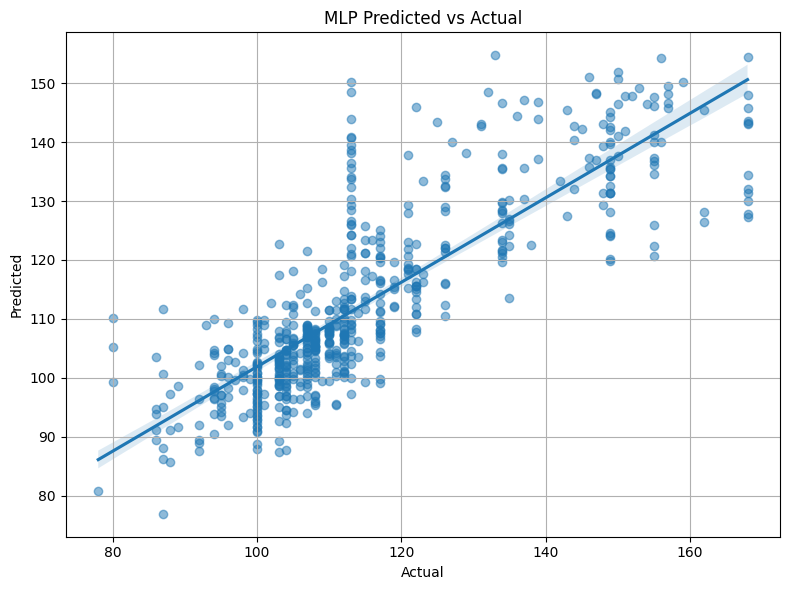

In [165]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

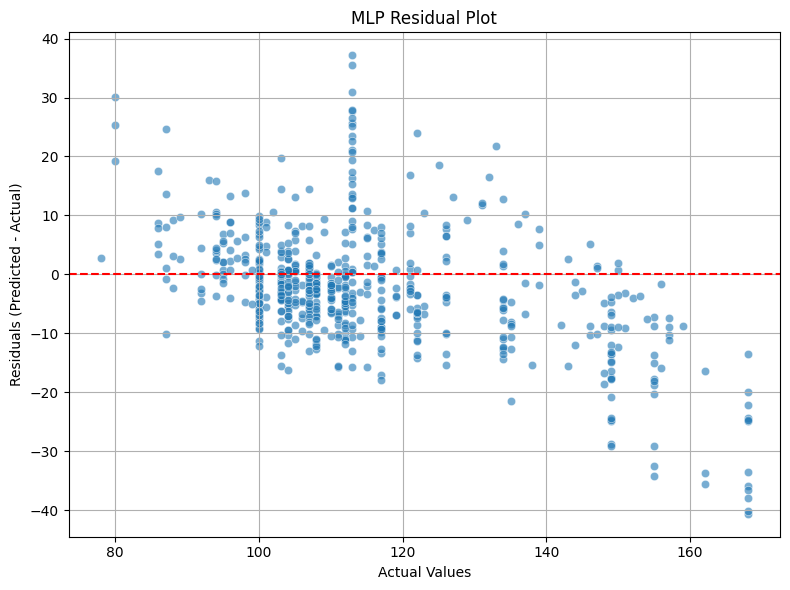

In [166]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only Location

In [167]:
pca_loc= X_dupe.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.003579,-0.081070,0.030498,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.001273,0.016743,0.025923,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,0.001582,0.006455,-0.010067,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.022296,0.007699,-0.011343,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.052144,0.060825,0.051451,0,1,0,0,0,1,0


In [168]:
pca_loc_dupe = X_dupe.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.003579,-0.081070,0.030498,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.001273,0.016743,0.025923,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,0.001582,0.006455,-0.010067,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.022296,0.007699,-0.011343,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.052144,0.060825,0.051451,0,1,0,0,0,1,0


In [169]:
X_tensor = torch.tensor(pca_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [170]:
print(X_tensor.shape)

torch.Size([2450, 207])


In [171]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [172]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 11:31:57,212] A new study created in memory with name: no-name-d078c8bf-201b-4869-97d8-5b7306f93ee1
[I 2025-05-26 11:32:03,554] Trial 0 finished with value: 90.58769989013672 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.02420995996384245, 'dropout2': 0.07437328928610862, 'lr': 0.0002878387119517434, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 15}. Best is trial 0 with value: 90.58769989013672.
[I 2025-05-26 11:32:06,268] Trial 1 finished with value: 95.67434692382812 and parameters: {'hidden_size1': 200, 'hidden_size2': 75, 'hidden_size3': 50, 'dropout1': 0.06392952422089028, 'dropout2': 0.08716285323698461, 'lr': 0.00047874570162841025, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 8}. Best is trial 0 with value: 90.58769989013672.
[I 2025-05-26 11:32:10,252] Trial 2 finished with value: 145.63455200195312 and parameters: {'hidden_size1': 100, 'hidden_size2': 75, 'hidden_size3'

Early stopping at epoch 49


[I 2025-05-26 11:32:15,931] Trial 3 finished with value: 311.1134033203125 and parameters: {'hidden_size1': 200, 'hidden_size2': 75, 'hidden_size3': 75, 'dropout1': 0.045610418768686246, 'dropout2': 0.03546865276371825, 'lr': 0.0014675774726269706, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 14}. Best is trial 0 with value: 90.58769989013672.
[I 2025-05-26 11:32:17,874] Trial 4 finished with value: 13041.064453125 and parameters: {'hidden_size1': 200, 'hidden_size2': 75, 'hidden_size3': 25, 'dropout1': 0.023316763298521587, 'dropout2': 0.08265544712523558, 'lr': 0.001295671305909957, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 13}. Best is trial 0 with value: 90.58769989013672.
[I 2025-05-26 11:32:21,068] Trial 5 finished with value: 13181.2041015625 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.01643897257890778, 'dropout2': 0.05391641577292357, 'lr': 0.0006204546352759701, 'batch_size': 64,

Early stopping at epoch 14


[I 2025-05-26 11:32:30,896] Trial 11 finished with value: 89.46533966064453 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout1': 0.08016897971513434, 'dropout2': 0.012201020362410619, 'lr': 0.0031749496043923207, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 11}. Best is trial 8 with value: 83.07640838623047.


...

Early stopping at epoch 32


[I 2025-05-26 11:33:38,846] Trial 47 finished with value: 81.80496215820312 and parameters: {'hidden_size1': 100, 'hidden_size2': 75, 'hidden_size3': 50, 'dropout1': 0.09267054460514518, 'dropout2': 0.024303125618936033, 'lr': 0.002424918430523148, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 13}. Best is trial 47 with value: 81.80496215820312.


Early stopping at epoch 50


[I 2025-05-26 11:33:43,375] Trial 48 finished with value: 75.86637115478516 and parameters: {'hidden_size1': 200, 'hidden_size2': 75, 'hidden_size3': 75, 'dropout1': 0.09979797715298522, 'dropout2': 0.024632516193097337, 'lr': 0.0024485058048967848, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 13}. Best is trial 48 with value: 75.86637115478516.
[I 2025-05-26 11:33:45,832] Trial 49 finished with value: 7208.23486328125 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.09999266617286771, 'dropout2': 0.013860816793340783, 'lr': 0.0022396690055013295, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 11}. Best is trial 48 with value: 75.86637115478516.


Best hyperparameters: {'hidden_size1': 200, 'hidden_size2': 75, 'hidden_size3': 75, 'dropout1': 0.09979797715298522, 'dropout2': 0.024632516193097337, 'lr': 0.0024485058048967848, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 13}


In [173]:
best_params = study.best_params

In [174]:
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_200_best_model_onlyloc_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 35 for fold 1
Fold 1 validation loss: 85.9593
Training fold 2
Early stopping at epoch 31 for fold 2
Fold 2 validation loss: 107.4091
Training fold 3
Early stopping at epoch 47 for fold 3
Fold 3 validation loss: 85.6214
Training fold 4
Early stopping at epoch 39 for fold 4
Fold 4 validation loss: 82.2065
Training fold 5
Early stopping at epoch 29 for fold 5
Fold 5 validation loss: 94.4388
Training fold 6
Early stopping at epoch 45 for fold 6
Fold 6 validation loss: 82.7402
Training fold 7
Early stopping at epoch 43 for fold 7
Fold 7 validation loss: 98.9312
Training fold 8
Early stopping at epoch 25 for fold 8
Fold 8 validation loss: 116.3447
Training fold 9
Early stopping at epoch 29 for fold 9
Fold 9 validation loss: 108.8694
Training fold 10
Early stopping at epoch 30 for fold 10
Fold 10 validation loss: 85.3155

Average validation loss across all folds: 94.7836
Checkpoint saved as 'pca_200_best_model_onlyloc_mlp_md.pth'.


In [175]:
X_holdout = pca_full_holdout.iloc[:, :511]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [176]:
y_holdout = pca_full_holdout.iloc[:, 511:]
y_holdout.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [177]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout = pca_loc_dupe.align(X_holdout, join='inner', axis=1)

In [178]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s2692 to s612
Columns: 207 entries, 1 to landrace
dtypes: float64(200), int64(7)
memory usage: 996.1+ KB


In [179]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [180]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 139.2801
RMSE: 11.8017
MAE: 7.6464
R2: 0.5887
Holdout_Loss: 139.2801


In [47]:
pickle.dump(best_mlp_model, open("pca_200_best_model_onlyloc_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 124.33663
1 115.0 117.72607
2 100.0 94.12003
3 107.0 106.144516
4 168.0 150.45876
5 150.0 140.56071


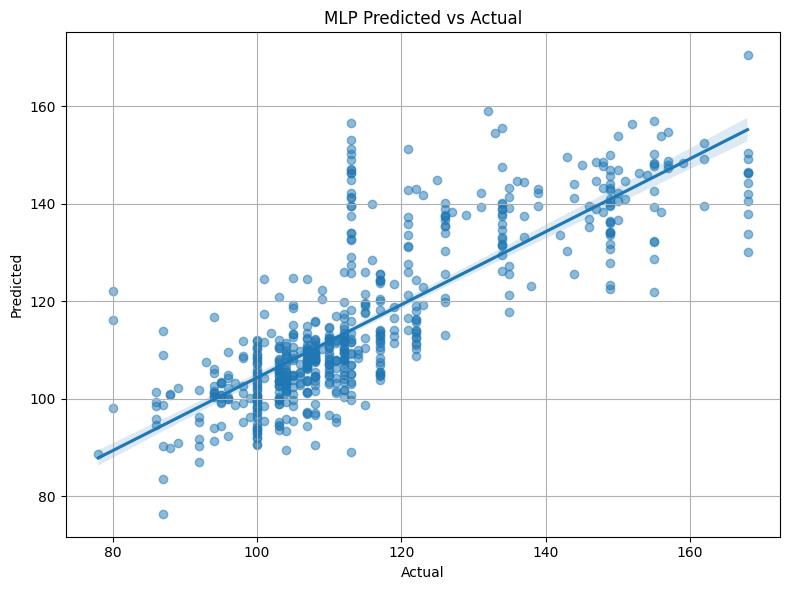

In [48]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

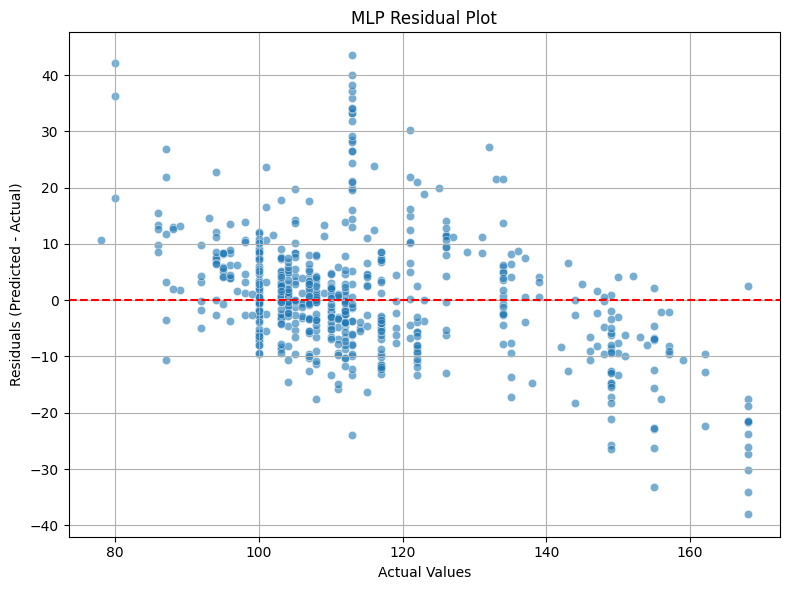

In [49]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only PCs

In [181]:
only_pca= pd.concat([pca_full_train.iloc[:, :200], pca_full_train.iloc[:, -3:]], axis=1)
only_pca= only_pca.drop(['MD'], axis=1)
only_pca.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,0.000610,0.020551,0.029000,-0.032989,0.020069,-0.003579,-0.081070,0.030498,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.004685,-0.021917,0.005822,0.029612,0.060264,-0.001273,0.016743,0.025923,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.000054,0.011717,-0.001412,0.008280,-0.023776,0.001582,0.006455,-0.010067,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.039625,-0.011997,-0.002396,0.006086,0.001528,0.022296,0.007699,-0.011343,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.054112,-0.037200,-0.008555,-0.018565,0.053066,-0.052144,0.060825,0.051451,1,0


In [182]:
only_pca_dupe = pd.concat([pca_full_train.iloc[:, :200], pca_full_train.iloc[:, -3:]], axis=1)
only_pca_dupe = only_pca_dupe .drop(['MD'], axis=1)
only_pca_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,0.000610,0.020551,0.029000,-0.032989,0.020069,-0.003579,-0.081070,0.030498,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.004685,-0.021917,0.005822,0.029612,0.060264,-0.001273,0.016743,0.025923,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.000054,0.011717,-0.001412,0.008280,-0.023776,0.001582,0.006455,-0.010067,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.039625,-0.011997,-0.002396,0.006086,0.001528,0.022296,0.007699,-0.011343,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.054112,-0.037200,-0.008555,-0.018565,0.053066,-0.052144,0.060825,0.051451,1,0


In [183]:
# Convert to tensor and move to GPU if available
X_tensor = torch.tensor(only_pca.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [184]:
print(X_tensor.shape)

torch.Size([2450, 202])


In [185]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [186]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 11:38:02,454] A new study created in memory with name: no-name-d856d927-8e00-4752-be5b-798dca462b1a
[I 2025-05-26 11:38:04,904] Trial 0 finished with value: 12013.3857421875 and parameters: {'hidden_size1': 75, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.0129706219661447, 'dropout2': 0.0594695045524606, 'lr': 0.0014786507296949834, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 12}. Best is trial 0 with value: 12013.3857421875.
[I 2025-05-26 11:38:05,591] Trial 1 finished with value: 355.1078186035156 and parameters: {'hidden_size1': 75, 'hidden_size2': 75, 'hidden_size3': 50, 'dropout1': 0.09316268199305835, 'dropout2': 0.0665314799564121, 'lr': 0.0006341590148832733, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 8}. Best is trial 1 with value: 355.1078186035156.


Early stopping at epoch 23


[I 2025-05-26 11:38:07,459] Trial 2 finished with value: 419.46734619140625 and parameters: {'hidden_size1': 100, 'hidden_size2': 75, 'hidden_size3': 75, 'dropout1': 0.012462821266235082, 'dropout2': 0.0539909555438109, 'lr': 0.004232725935948849, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 13}. Best is trial 1 with value: 355.1078186035156.


Early stopping at epoch 22


[I 2025-05-26 11:38:08,996] Trial 3 finished with value: 343.8375549316406 and parameters: {'hidden_size1': 75, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.060583601693721796, 'dropout2': 0.056589223399564605, 'lr': 0.00038490495470947086, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 7}. Best is trial 3 with value: 343.8375549316406.


...

Early stopping at epoch 16


[I 2025-05-26 11:39:33,528] Trial 47 finished with value: 348.160400390625 and parameters: {'hidden_size1': 75, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout1': 0.06261709563557843, 'dropout2': 0.054088455995702375, 'lr': 0.00022422804526161163, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 15}. Best is trial 14 with value: 337.5044250488281.


Early stopping at epoch 30


[I 2025-05-26 11:39:34,907] Trial 48 finished with value: 13534.0732421875 and parameters: {'hidden_size1': 100, 'hidden_size2': 75, 'hidden_size3': 25, 'dropout1': 0.09488780690835712, 'dropout2': 0.08141598684887306, 'lr': 0.000306015741307851, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 5}. Best is trial 14 with value: 337.5044250488281.
[I 2025-05-26 11:39:35,436] Trial 49 finished with value: 374.93463134765625 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.03059218652745163, 'dropout2': 0.038166354917818224, 'lr': 0.009837863903610546, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 6}. Best is trial 14 with value: 337.5044250488281.


Early stopping at epoch 17
Best hyperparameters: {'hidden_size1': 75, 'hidden_size2': 75, 'hidden_size3': 25, 'dropout1': 0.04486444904328394, 'dropout2': 0.027105612788624583, 'lr': 0.00010543472340159467, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 10}


In [187]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='"pca_200_best_model_onlypcs_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 343.0462
Training fold 2
Fold 2 validation loss: 402.3138
Training fold 3
Fold 3 validation loss: 365.7551
Training fold 4
Fold 4 validation loss: 338.2231
Training fold 5
Fold 5 validation loss: 361.3219
Training fold 6
Fold 6 validation loss: 342.4108
Training fold 7
Fold 7 validation loss: 340.9793
Training fold 8
Fold 8 validation loss: 343.2579
Training fold 9
Fold 9 validation loss: 401.1579
Training fold 10
Fold 10 validation loss: 292.1296

Average validation loss across all folds: 353.0596
Checkpoint saved as '"pca_200_best_model_onlypcs_mlp_md.pth'.


In [188]:
best_mlp_model

Sequential(
  (0): Linear(in_features=202, out_features=75, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.04486444904328394, inplace=False)
  (3): Linear(in_features=75, out_features=75, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.027105612788624583, inplace=False)
  (6): Linear(in_features=75, out_features=25, bias=True)
  (7): ReLU()
  (8): Linear(in_features=25, out_features=1, bias=True)
)

In [189]:
pca_full_holdout = pd.read_pickle("pickle_files/pca_full_holdout_md.pkl")
pca_full_holdout = pca_full_holdout.reset_index().set_index('Line')
pca_full_holdout = pca_full_holdout.drop(['index','new_line'], axis=1)
pca_full_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [190]:
X_holdout = pca_full_holdout.iloc[:, :511]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [191]:
y_holdout = pca_full_holdout.iloc[:, 511:]
y_holdout.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [192]:
# Ensure both training and holdout datasets have the same columns
only_pca_dupe, X_holdout =only_pca_dupe.align(X_holdout, join='inner', axis=1)

In [193]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s2692 to s612
Columns: 202 entries, 1 to landrace
dtypes: float64(200), int64(2)
memory usage: 972.2+ KB


In [194]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [195]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 331.3199
RMSE: 18.2022
MAE: 13.8219
R2: 0.0216
Holdout_Loss: 331.3199


In [82]:
pickle.dump(best_mlp_model, open("pca_200_best_model_onlypcs_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

## PC500 

### All covariates

In [196]:
y_all = pca_full_train.iloc[:, 511:]
y_all.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [197]:
X_all = pca_full_train.iloc[:, 0:511]
X_all.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [198]:
X_all_dupe = pca_full_train.iloc[:, 0:511]
X_all_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [199]:
X_tensor = torch.tensor(X_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [200]:
print(X_tensor.shape)

torch.Size([2450, 511])


In [201]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [202]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 11:41:28,798] A new study created in memory with name: no-name-5775e28b-58a1-4f62-8a75-d4addfd1f245
[I 2025-05-26 11:41:31,338] Trial 0 finished with value: 90.16763305664062 and parameters: {'hidden_size1': 75, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.06118896353158299, 'dropout2': 0.04752392839499186, 'lr': 0.0006916850048833133, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 5}. Best is trial 0 with value: 90.16763305664062.
[I 2025-05-26 11:41:33,776] Trial 1 finished with value: 12854.96484375 and parameters: {'hidden_size1': 75, 'hidden_size2': 75, 'hidden_size3': 50, 'dropout1': 0.06668285830350852, 'dropout2': 0.06283367846420108, 'lr': 0.00018111019589772649, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 15}. Best is trial 0 with value: 90.16763305664062.
[I 2025-05-26 11:41:38,044] Trial 2 finished with value: 131.19754028320312 and parameters: {'hidden_size1': 75, 'hidden_size2': 100, 'hidden_size3': 75, 

Early stopping at epoch 69


[I 2025-05-26 11:41:47,300] Trial 4 finished with value: 97.86577606201172 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.01720860745638606, 'dropout2': 0.07796260057340071, 'lr': 0.00027443555127561485, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 13}. Best is trial 0 with value: 90.16763305664062.
[I 2025-05-26 11:41:48,134] Trial 5 finished with value: 9346.8466796875 and parameters: {'hidden_size1': 75, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.037523469631400685, 'dropout2': 0.05869679660031625, 'lr': 0.0015598987992449952, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 13}. Best is trial 0 with value: 90.16763305664062.
[I 2025-05-26 11:41:49,505] Trial 6 finished with value: 819.6728515625 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.03879590583042823, 'dropout2': 0.0401034173297942, 'lr': 0.004132583912260084, 'batch_size': 64,

Early stopping at epoch 42


[I 2025-05-26 11:41:54,109] Trial 9 finished with value: 107.2708740234375 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.019872356711075033, 'dropout2': 0.030299451542450354, 'lr': 0.0012641163314398797, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 7}. Best is trial 0 with value: 90.16763305664062.


...

Early stopping at epoch 47


[I 2025-05-26 11:43:22,723] Trial 48 finished with value: 86.35840606689453 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.05213060479184142, 'dropout2': 0.01716322219978715, 'lr': 0.0014684350798099904, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 10}. Best is trial 48 with value: 86.35840606689453.


Early stopping at epoch 46


[I 2025-05-26 11:43:25,896] Trial 49 finished with value: 101.91036987304688 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.051302819413108464, 'dropout2': 0.019575507859666455, 'lr': 0.0013846743500538618, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 9}. Best is trial 48 with value: 86.35840606689453.


Early stopping at epoch 34
Best hyperparameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.05213060479184142, 'dropout2': 0.01716322219978715, 'lr': 0.0014684350798099904, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 10}


In [203]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_500_best_model_allfeats_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 76.8396
Training fold 2
Fold 2 validation loss: 92.9229
Training fold 3
Early stopping at epoch 47 for fold 3
Fold 3 validation loss: 116.5932
Training fold 4
Early stopping at epoch 68 for fold 4
Fold 4 validation loss: 74.6441
Training fold 5
Early stopping at epoch 55 for fold 5
Fold 5 validation loss: 102.8295
Training fold 6
Fold 6 validation loss: 88.2230
Training fold 7
Early stopping at epoch 67 for fold 7
Fold 7 validation loss: 103.2422
Training fold 8
Early stopping at epoch 41 for fold 8
Fold 8 validation loss: 147.6640
Training fold 9
Fold 9 validation loss: 111.0822
Training fold 10
Fold 10 validation loss: 100.5573

Average validation loss across all folds: 101.4598
Checkpoint saved as 'pca_500_best_model_allfeats_mlp_md.pth'.


In [204]:
best_mlp_model

Sequential(
  (0): Linear(in_features=511, out_features=200, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.05213060479184142, inplace=False)
  (3): Linear(in_features=200, out_features=50, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.01716322219978715, inplace=False)
  (6): Linear(in_features=50, out_features=50, bias=True)
  (7): ReLU()
  (8): Linear(in_features=50, out_features=1, bias=True)
)

In [205]:
X_holdout = pca_full_holdout.iloc[:, 0:511]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [206]:
y_holdout = pca_full_holdout.iloc[:, 511:]
y_holdout.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [207]:
# Ensure both training and holdout datasets have the same columns
X_all_dupe, X_holdout = X_all_dupe.align(X_holdout, join='inner', axis=1)

In [208]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s2692 to s612
Columns: 511 entries, 1 to landrace
dtypes: float64(504), int64(7)
memory usage: 2.4+ MB


In [209]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [210]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 120.2432
RMSE: 10.9655
MAE: 7.8208
R2: 0.6449
Holdout_Loss: 120.2432


In [100]:
pickle.dump(best_mlp_model, open("pca_500_best_model_allfeats_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 123.520424
1 115.0 125.08371
2 100.0 99.28462
3 107.0 106.13309
4 168.0 148.02005
5 150.0 143.86174


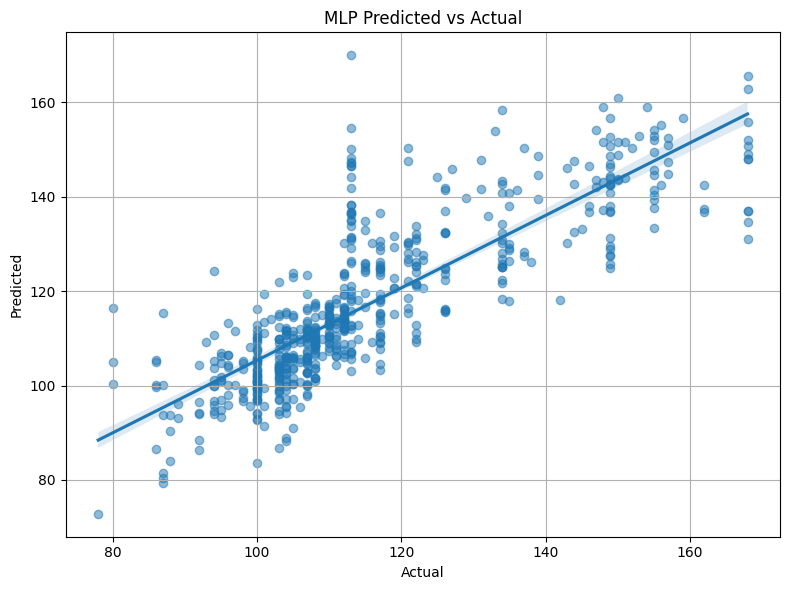

In [101]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

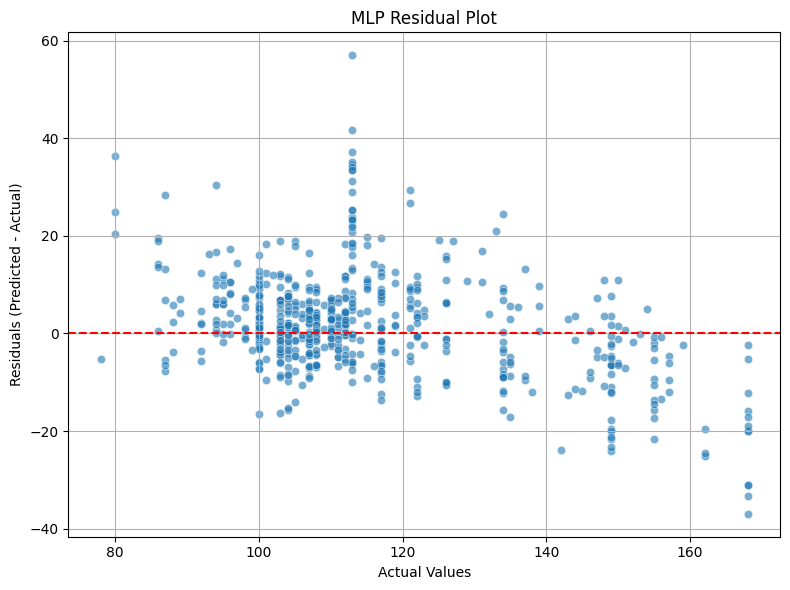

In [102]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [103]:
pca_loc= X_all_dupe.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,498,499,500,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.021508,-0.024271,-0.011418,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,0.005446,0.019524,0.054528,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,0.007665,-0.009861,-0.004266,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.029024,0.018871,-0.007392,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,0.025662,0.057667,0.006056,0,1,0,0,0,1,0


In [104]:
pca_loc_dupe = X_all_dupe.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe .head()

,1,2,3,4,5,6,7,8,9,10,...,498,499,500,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.021508,-0.024271,-0.011418,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,0.005446,0.019524,0.054528,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,0.007665,-0.009861,-0.004266,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.029024,0.018871,-0.007392,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,0.025662,0.057667,0.006056,0,1,0,0,0,1,0


In [106]:
y = pca_full_train.iloc[:, 511:]
y.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [107]:
X_tensor = torch.tensor(pca_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [108]:
print(X_tensor.shape)

torch.Size([2450, 507])


In [109]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [110]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 11:05:17,356] A new study created in memory with name: no-name-789ebe54-2159-4472-8ffb-e336c81d8b9b
[I 2025-05-26 11:05:18,301] Trial 0 finished with value: 89.08038330078125 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout1': 0.05963514850502131, 'dropout2': 0.01658136723807236, 'lr': 0.0030642976422193455, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 10}. Best is trial 0 with value: 89.08038330078125.


Early stopping at epoch 31


[I 2025-05-26 11:05:19,056] Trial 1 finished with value: 100.63126373291016 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.06142683956531274, 'dropout2': 0.03280211372301621, 'lr': 0.0023530936552743176, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 6}. Best is trial 0 with value: 89.08038330078125.


Early stopping at epoch 26


[I 2025-05-26 11:05:20,185] Trial 2 finished with value: 119.50235748291016 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.09830163705112689, 'dropout2': 0.09305122690069235, 'lr': 0.0023120900917184555, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 14}. Best is trial 0 with value: 89.08038330078125.


...

Early stopping at epoch 23


[I 2025-05-26 11:07:56,000] Trial 47 finished with value: 103.8595199584961 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.02144694547763255, 'dropout2': 0.05075939385354289, 'lr': 0.0013853541562031558, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 8}. Best is trial 25 with value: 76.4888687133789.


Early stopping at epoch 41


[I 2025-05-26 11:07:59,533] Trial 48 finished with value: 81.35174560546875 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.014615564126699518, 'dropout2': 0.042054650423127934, 'lr': 0.00023982307297040767, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 6}. Best is trial 25 with value: 76.4888687133789.
[I 2025-05-26 11:08:04,984] Trial 49 finished with value: 79.64163970947266 and parameters: {'hidden_size1': 300, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.024650339109082164, 'dropout2': 0.03047325680962032, 'lr': 0.00037614065983034115, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 9}. Best is trial 25 with value: 76.4888687133789.


Early stopping at epoch 60
Best hyperparameters: {'hidden_size1': 300, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.01999217652636628, 'dropout2': 0.05103584585947237, 'lr': 0.00015354871660032467, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 8}


In [111]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_500_best_model_onlyloc_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 77.3144
Training fold 2
Early stopping at epoch 65 for fold 2
Fold 2 validation loss: 110.5785
Training fold 3
Early stopping at epoch 45 for fold 3
Fold 3 validation loss: 106.6810
Training fold 4
Early stopping at epoch 48 for fold 4
Fold 4 validation loss: 94.9091
Training fold 5
Fold 5 validation loss: 88.3416
Training fold 6
Early stopping at epoch 57 for fold 6
Fold 6 validation loss: 88.7718
Training fold 7
Fold 7 validation loss: 106.7747
Training fold 8
Early stopping at epoch 28 for fold 8
Fold 8 validation loss: 143.8436
Training fold 9
Fold 9 validation loss: 109.5303
Training fold 10
Fold 10 validation loss: 92.8251

Average validation loss across all folds: 101.9570
Checkpoint saved as 'pca_500_best_model_onlyloc_mlp_md.pth'.


In [112]:
pca_full_holdout = pd.read_pickle("pickle_files/pca_full_holdout_md.pkl")
pca_full_holdout = pca_full_holdout.reset_index().set_index('Line')
pca_full_holdout = pca_full_holdout.drop(['index','new_line'], axis=1)
pca_full_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [113]:
X_holdout = pca_full_holdout.iloc[:, :511]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [114]:
y_holdout = pca_full_holdout.iloc[:, 511:]
y_holdout.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [115]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout = pca_loc_dupe.align(X_holdout, join='inner', axis=1)

In [117]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s2692 to s612
Columns: 507 entries, 1 to landrace
dtypes: float64(500), int64(7)
memory usage: 2.4+ MB


In [118]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [119]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 107.8209
RMSE: 10.3837
MAE: 7.6839
R2: 0.6816
Holdout_Loss: 107.8209


In [120]:
pickle.dump(best_mlp_model, open("'pca_500_best_model_onlyloc_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 123.61804
1 115.0 119.70344
2 100.0 94.214775
3 107.0 107.29952
4 168.0 140.88025
5 150.0 141.61662


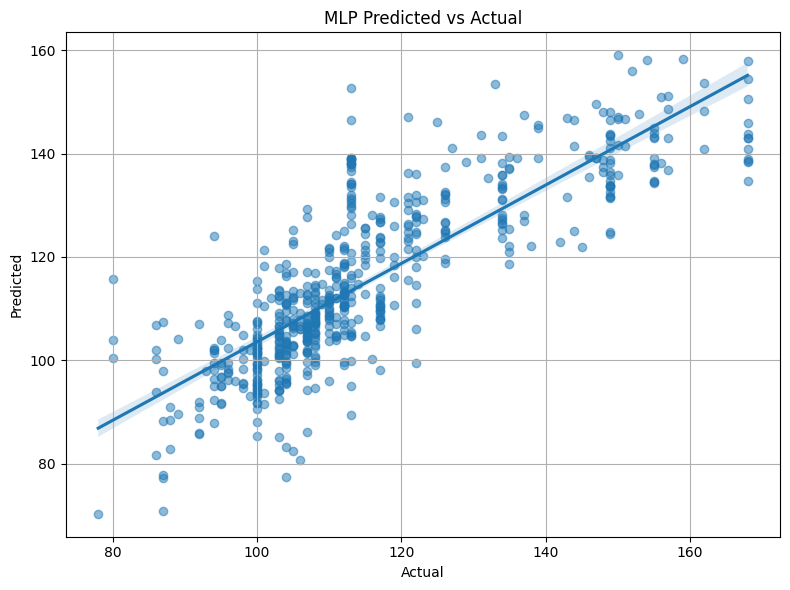

In [121]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

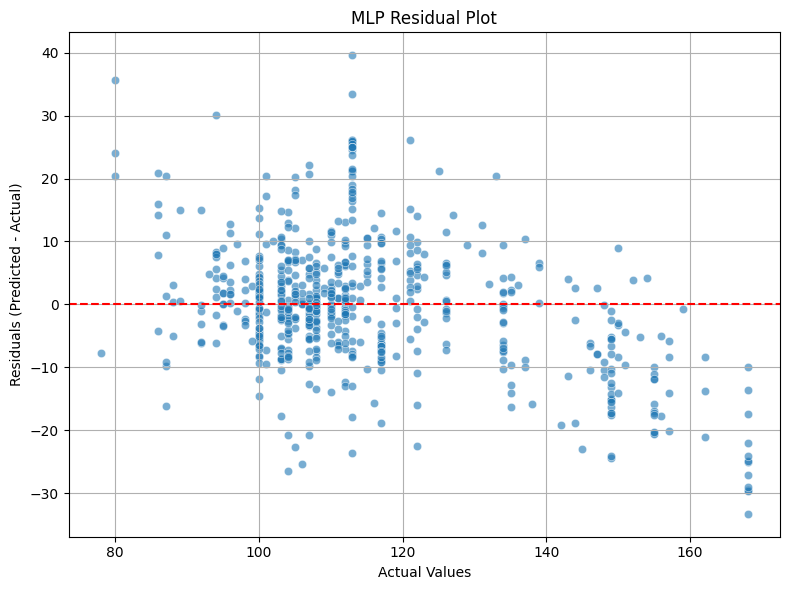

In [122]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [123]:
y = pca_full_train.iloc[:, 511:]
y.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [124]:
pca_only =  pca_full_train.iloc[:, :500]
pca_only.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.023536,0.002960,0.004914,-0.011766,0.002108,-0.010215,0.018547,-0.021508,-0.024271,-0.011418
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,0.009285,0.032270,0.017829,0.003439,0.045344,-0.039668,-0.068647,0.005446,0.019524,0.054528
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.009431,-0.004633,0.011966,0.005379,0.002594,0.003557,-0.000194,0.007665,-0.009861,-0.004266
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,-0.028132,-0.025362,0.037080,0.003618,-0.062027,-0.041410,0.019568,0.029024,0.018871,-0.007392
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,0.006723,-0.006412,-0.002909,-0.017702,0.030001,0.010845,0.052283,0.025662,0.057667,0.006056


In [125]:
pca_only_dupe =  pca_full_train.iloc[:, :500]
pca_only_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.023536,0.002960,0.004914,-0.011766,0.002108,-0.010215,0.018547,-0.021508,-0.024271,-0.011418
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,0.009285,0.032270,0.017829,0.003439,0.045344,-0.039668,-0.068647,0.005446,0.019524,0.054528
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.009431,-0.004633,0.011966,0.005379,0.002594,0.003557,-0.000194,0.007665,-0.009861,-0.004266
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,-0.028132,-0.025362,0.037080,0.003618,-0.062027,-0.041410,0.019568,0.029024,0.018871,-0.007392
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,0.006723,-0.006412,-0.002909,-0.017702,0.030001,0.010845,0.052283,0.025662,0.057667,0.006056


In [126]:
X_tensor = torch.tensor(pca_only.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [127]:
print(X_tensor.shape)

torch.Size([2450, 500])


In [128]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [129]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 11:17:41,650] A new study created in memory with name: no-name-aaf56f45-a90d-4eab-baa9-7149469c6e55
[I 2025-05-26 11:17:43,045] Trial 0 finished with value: 13531.5361328125 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout1': 0.06591067951755773, 'dropout2': 0.07742838019728118, 'lr': 0.0002683672851811678, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 9}. Best is trial 0 with value: 13531.5361328125.
[I 2025-05-26 11:17:44,563] Trial 1 finished with value: 379.6982727050781 and parameters: {'hidden_size1': 300, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.040888689262126104, 'dropout2': 0.08638759507696896, 'lr': 0.00013842267033018947, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 8}. Best is trial 1 with value: 379.6982727050781.
[I 2025-05-26 11:17:45,955] Trial 2 finished with value: 13490.001953125 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'hidden_size3': 7

Early stopping at epoch 35


[I 2025-05-26 11:17:49,777] Trial 5 finished with value: 410.7137145996094 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout1': 0.01078208857961471, 'dropout2': 0.01617260773940573, 'lr': 0.003487061544500921, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 14}. Best is trial 4 with value: 376.0517272949219.


Early stopping at epoch 27


[I 2025-05-26 11:17:51,804] Trial 6 finished with value: 389.4823913574219 and parameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.055238280344584195, 'dropout2': 0.06581407065537187, 'lr': 0.0001780894736467727, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 13}. Best is trial 4 with value: 376.0517272949219.
[I 2025-05-26 11:17:52,718] Trial 7 finished with value: 388.3802795410156 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.04484696919612573, 'dropout2': 0.017774425092316557, 'lr': 0.00024437115512116695, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 14}. Best is trial 4 with value: 376.0517272949219.
[I 2025-05-26 11:17:55,272] Trial 8 finished with value: 390.9511413574219 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout1': 0.02826515686469694, 'dropout2': 0.05523347139499216, 'lr': 0.0009923291141949852, 'bat

...

Early stopping at epoch 41


[I 2025-05-26 11:19:51,995] Trial 42 finished with value: 336.9521179199219 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.06312134460099006, 'dropout2': 0.06444775247083441, 'lr': 0.009977087897805785, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 9}. Best is trial 29 with value: 333.4761047363281.
[I 2025-05-26 11:19:56,064] Trial 43 finished with value: 340.0882263183594 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout1': 0.07912093458107623, 'dropout2': 0.052908438611176695, 'lr': 0.003560251688974494, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 8}. Best is trial 29 with value: 333.4761047363281.
[I 2025-05-26 11:19:57,468] Trial 44 finished with value: 5648.86962890625 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.09146705582147271, 'dropout2': 0.05946944947437972, 'lr': 0.006606861922729012, 'batch_size': 1

Early stopping at epoch 37


[I 2025-05-26 11:20:12,489] Trial 49 finished with value: 342.07501220703125 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.08851655688222305, 'dropout2': 0.03986371076750822, 'lr': 0.004095274714946098, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 10}. Best is trial 29 with value: 333.4761047363281.


Best hyperparameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.07127089684052787, 'dropout2': 0.05781963129230982, 'lr': 0.009409716008490294, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 8}


In [130]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_500_best_model_onlypcs_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 20 for fold 1
Fold 1 validation loss: 333.9582
Training fold 2
Early stopping at epoch 19 for fold 2
Fold 2 validation loss: 403.6953
Training fold 3
Early stopping at epoch 12 for fold 3
Fold 3 validation loss: 373.2517
Training fold 4
Early stopping at epoch 20 for fold 4
Fold 4 validation loss: 339.8011
Training fold 5
Early stopping at epoch 16 for fold 5
Fold 5 validation loss: 361.5126
Training fold 6
Early stopping at epoch 14 for fold 6
Fold 6 validation loss: 342.5534
Training fold 7
Early stopping at epoch 16 for fold 7
Fold 7 validation loss: 349.3076
Training fold 8
Early stopping at epoch 10 for fold 8
Fold 8 validation loss: 350.3510
Training fold 9
Early stopping at epoch 16 for fold 9
Fold 9 validation loss: 414.5990
Training fold 10
Early stopping at epoch 15 for fold 10
Fold 10 validation loss: 289.5853

Average validation loss across all folds: 355.8615
Checkpoint saved as 'pca_500_best_model_onlypcs_mlp_md.pth'.


In [131]:
pca_full_holdout = pd.read_pickle("pickle_files/pca_full_holdout_md.pkl")
pca_full_holdout = pca_full_holdout.reset_index().set_index('Line')
pca_full_holdout = pca_full_holdout.drop(['index','new_line'], axis=1)
pca_full_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [132]:
X_holdout = pca_full_holdout.iloc[:, :511]
X_holdout.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [133]:
y_holdout = pca_full_holdout.iloc[:, 511:]
y_holdout.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [134]:
# Ensure both training and holdout datasets have the same columns
pca_only_dupe, X_holdout = pca_only_dupe.align(X_holdout, join='inner', axis=1)

In [135]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s2692 to s612
Columns: 500 entries, 1 to 500
dtypes: float64(500)
memory usage: 2.3+ MB


In [137]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [138]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 348.0591
RMSE: 18.6563
MAE: 14.1974
R2: -0.0278
Holdout_Loss: 348.0591


In [139]:
pickle.dump(best_mlp_model, open("'pca_500_best_model_onlypcs_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 113.83693
1 115.0 129.755
2 100.0 116.27335
3 107.0 110.74359
4 168.0 114.01596
5 150.0 109.02028


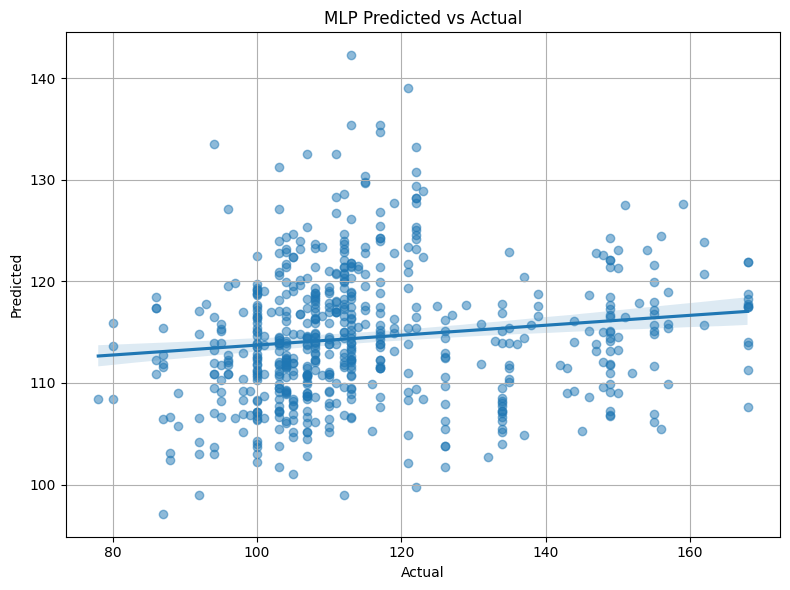

In [140]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

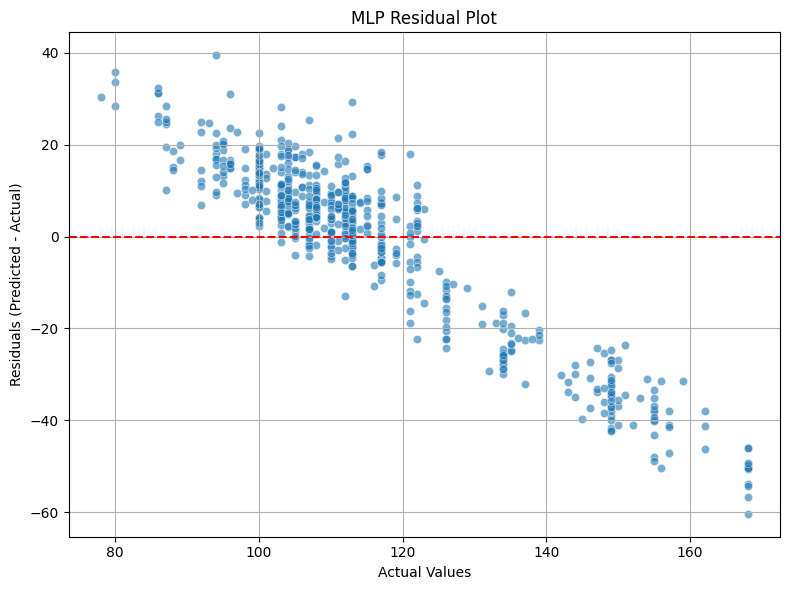

In [141]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

# GWAS

## GWAS top 1%

### All covariates

In [27]:
gwas_data = pd.read_pickle("pickle_files/GWAS_top1percent_md_data.pkl")
gwas_data.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,0,2,0,0,0,0,1,0,2,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s101,0,2,2,0,0,0,0,1,0,0,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
s1014,0,0,0,0,1,0,1,1,0,2,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,1,0,1,1,0,2,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


In [28]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 2524 entries, Chr1_123617 to MD
dtypes: float64(5), int64(2519)
memory usage: 47.2+ MB


In [29]:
gwas_y = gwas_data.iloc[:, 2523:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [30]:
gwas_all= gwas_data.drop(['MD'], axis=1)
gwas_all.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


In [31]:
gwas_all_dupe= gwas_data.drop(['MD'], axis=1)
gwas_all_dupe.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


In [32]:
X_tensor = torch.tensor(gwas_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [33]:
print(X_tensor.shape)

torch.Size([2450, 2523])


In [34]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [35]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 14:22:04,223] A new study created in memory with name: no-name-d2cd2293-cd2c-43e8-80bf-21bd3a57439a
[I 2025-05-26 14:22:05,901] Trial 0 finished with value: 172.45619201660156 and parameters: {'hidden_size1': 300, 'dropout1': 0.01588064542561031, 'lr': 0.00024264241856068646, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.004633747711836762, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 172.45619201660156.


Early stopping at epoch 38


[I 2025-05-26 14:22:13,337] Trial 1 finished with value: 191.03216552734375 and parameters: {'hidden_size1': 300, 'dropout1': 0.028491174115259206, 'lr': 0.004328344965447494, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.00047113787721391734, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 172.45619201660156.
[I 2025-05-26 14:22:16,649] Trial 2 finished with value: 143.28282165527344 and parameters: {'hidden_size1': 200, 'dropout1': 0.07763593134342922, 'lr': 0.0014730100347645245, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 1.244461767464699e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 2 with value: 143.28282165527344.


Early stopping at epoch 76


[I 2025-05-26 14:22:20,079] Trial 3 finished with value: 128.6417236328125 and parameters: {'hidden_size1': 300, 'dropout1': 0.0789707034237104, 'lr': 0.000496291467328063, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0014843674851209112, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 3 with value: 128.6417236328125.


...

Early stopping at epoch 86


[I 2025-05-26 14:25:54,920] Trial 46 finished with value: 123.24224853515625 and parameters: {'hidden_size1': 300, 'dropout1': 0.04050248255127963, 'lr': 0.00040243004121736785, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 2.1363082791514515e-05, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout2': 0.01482286203073252}. Best is trial 34 with value: 96.49362182617188.


Early stopping at epoch 49


[I 2025-05-26 14:25:59,042] Trial 47 finished with value: 141.2442626953125 and parameters: {'hidden_size1': 200, 'dropout1': 0.08300189187073019, 'lr': 0.00021648991186501199, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 1.0630799886517348e-05, 'n_layers': 1}. Best is trial 34 with value: 96.49362182617188.
[I 2025-05-26 14:26:05,599] Trial 48 finished with value: 231.9376983642578 and parameters: {'hidden_size1': 100, 'dropout1': 0.07615623959359305, 'lr': 0.0018010380107211183, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 3.3549831839661965e-05, 'n_layers': 1}. Best is trial 34 with value: 96.49362182617188.
[I 2025-05-26 14:26:09,909] Trial 49 finished with value: 106.8004379272461 and parameters: {'hidden_size1': 300, 'dropout1': 0.05100236954819471, 'lr': 0.0005679784673473767, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 5.9108443213717284e-05, 'n_layers': 1}. Best is trial 34 with value: 96.49362182617188.


Early stopping at epoch 64
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.08953459990738175, 'lr': 0.0002957740684368497, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.4486506969412243e-05, 'n_layers': 1}


In [36]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top1_best_model_allfeats_mlp_md_test.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 94.4926
Training fold 2
Fold 2 validation loss: 104.3099
Training fold 3
Fold 3 validation loss: 119.6449
Training fold 4
Fold 4 validation loss: 108.5237
Training fold 5
Fold 5 validation loss: 126.2607
Training fold 6
Fold 6 validation loss: 121.8084
Training fold 7
Fold 7 validation loss: 107.8951
Training fold 8
Fold 8 validation loss: 105.7651
Training fold 9
Fold 9 validation loss: 132.2733
Training fold 10
Fold 10 validation loss: 109.9623

Average validation loss across all folds: 113.0936
Checkpoint saved as 'gwas_top1_best_model_allfeats_mlp_md_test.pth'.


In [37]:
best_mlp_model

Sequential(
  (0): Linear(in_features=2523, out_features=300, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.08953459990738175, inplace=False)
  (3): Linear(in_features=300, out_features=1, bias=True)
)

In [38]:
print("Best hyperparameters found by Optuna:")
for key, value in best_params.items():
    print(f"{key}: {value}")

Best hyperparameters found by Optuna:
hidden_size1: 300
dropout1: 0.08953459990738175
lr: 0.0002957740684368497
batch_size: 32
optimizer: Adam
weight_decay: 1.4486506969412243e-05
n_layers: 1
num_epochs: 100
patience: 10


In [39]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [40]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [41]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [42]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [43]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [44]:
X_holdout.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,1,0,0,0,0,1,1,0,1,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [45]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 2523 entries, Chr1_123617 to landrace
dtypes: float64(4), int64(2519)
memory usage: 11.8+ MB


In [46]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [47]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 143.0847
RMSE: 11.9618
MAE: 8.7541
R2: 0.6171
Holdout_Loss: 143.0847


In [48]:
pickle.dump(best_mlp_model, open("gwas_top1_best_model_allfeats_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 117.22645
1 148.0 151.04329
2 117.0 114.14714
3 121.0 119.934395
4 119.0 119.805466
5 94.0 100.76028


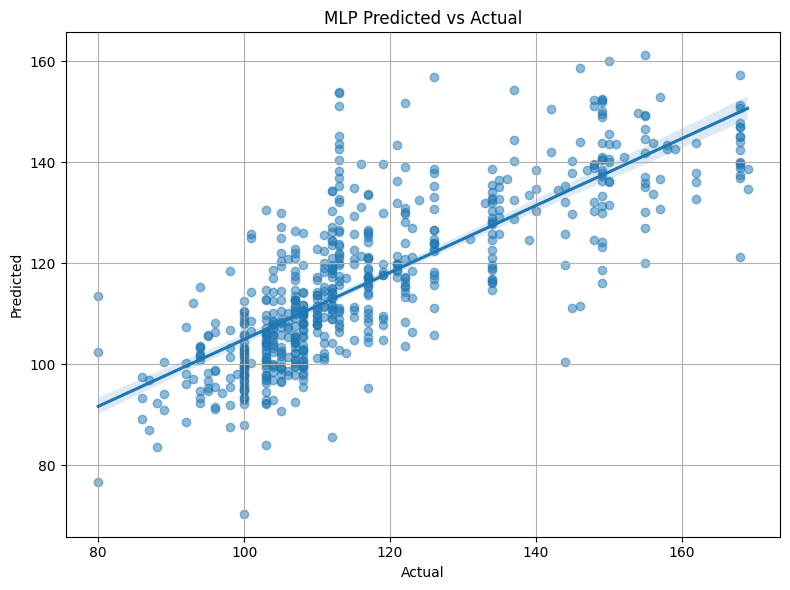

In [49]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

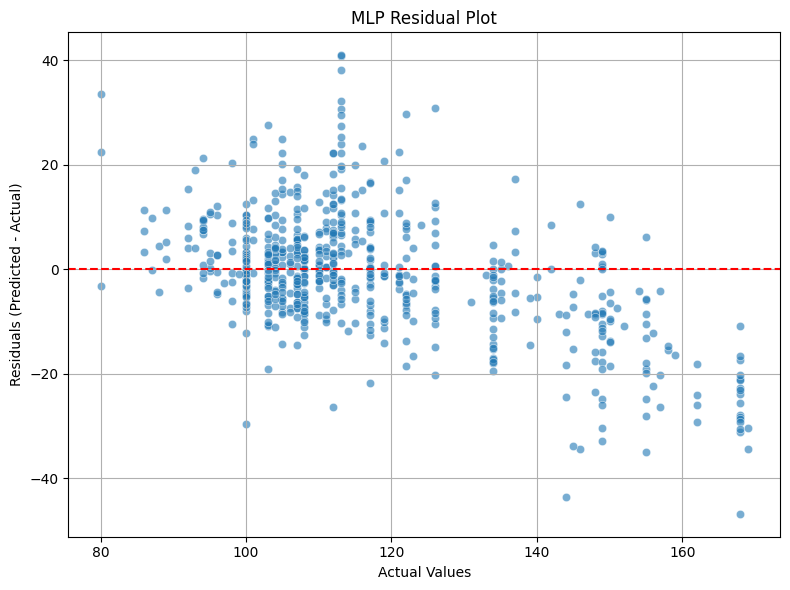

In [50]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [51]:
gwas_loc= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_50059719,Chr20_50927742,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,1,1,0,0,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,1,0,0,1,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,0,0,1,0,0,0,1,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,1,0,0,0,1


In [52]:
gwas_loc_dupe= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc_dupe.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_50059719,Chr20_50927742,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,1,1,0,0,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,1,0,0,1,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,0,0,1,0,0,0,1,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,1,0,0,0,1


In [53]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 2519 entries, Chr1_123617 to landrace
dtypes: int64(2519)
memory usage: 47.1+ MB


In [54]:
gwas_y = gwas_data.iloc[:, 2523:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [55]:
X_tensor = torch.tensor(gwas_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [56]:
print(X_tensor.shape)

torch.Size([2450, 2519])


In [57]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [58]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 14:30:40,889] A new study created in memory with name: no-name-c7fc61ae-2b33-4ac7-8d75-59720d039de9
[I 2025-05-26 14:30:46,917] Trial 0 finished with value: 108.6991195678711 and parameters: {'hidden_size1': 100, 'dropout1': 0.09072567928450022, 'lr': 0.0009565719476039337, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.00020316351978856334, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 108.6991195678711.


Early stopping at epoch 73


[I 2025-05-26 14:30:54,098] Trial 1 finished with value: 92.2435073852539 and parameters: {'hidden_size1': 100, 'dropout1': 0.08429086408406139, 'lr': 0.000657331451676374, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0003434444878997905, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 1 with value: 92.2435073852539.


Early stopping at epoch 86


[I 2025-05-26 14:30:57,807] Trial 2 finished with value: 5630.23388671875 and parameters: {'hidden_size1': 300, 'dropout1': 0.01970443785258991, 'lr': 0.0005398318022151774, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0011409170513295296, 'n_layers': 1}. Best is trial 1 with value: 92.2435073852539.
[I 2025-05-26 14:31:02,611] Trial 3 finished with value: 203.5213623046875 and parameters: {'hidden_size1': 200, 'dropout1': 0.05059382963577459, 'lr': 0.00918802122175526, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0007124552057289481, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout2': 0.06712966475839634}. Best is trial 1 with value: 92.2435073852539.
[I 2025-05-26 14:31:04,070] Trial 4 finished with value: 266.8579406738281 and parameters: {'hidden_size1': 100, 'dropout1': 0.09088676092933456, 'lr': 0.003461550632121562, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0002127987800468158, 'n_layers': 2, 'hidden_size2': 150}. Best is tri

...

Early stopping at epoch 76


[I 2025-05-26 14:34:12,853] Trial 45 finished with value: 363.9623718261719 and parameters: {'hidden_size1': 300, 'dropout1': 0.09993970151175897, 'lr': 0.001078240455010506, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0012347813878655282, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 42 with value: 77.02860260009766.
[I 2025-05-26 14:34:14,652] Trial 46 finished with value: 222.30862426757812 and parameters: {'hidden_size1': 300, 'dropout1': 0.0822483635831214, 'lr': 0.0013984137712720855, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0030259731968528165, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 42 with value: 77.02860260009766.


Early stopping at epoch 38


[I 2025-05-26 14:34:18,821] Trial 47 finished with value: 85.0338363647461 and parameters: {'hidden_size1': 300, 'dropout1': 0.09166480554224173, 'lr': 0.0005935565155720911, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0008081062749470052, 'n_layers': 1}. Best is trial 42 with value: 77.02860260009766.
[I 2025-05-26 14:34:22,923] Trial 48 finished with value: 84.34689331054688 and parameters: {'hidden_size1': 300, 'dropout1': 0.07570562975661256, 'lr': 0.0008913382889901019, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0008877628137818152, 'n_layers': 1}. Best is trial 42 with value: 77.02860260009766.
[I 2025-05-26 14:34:25,294] Trial 49 finished with value: 10342.0478515625 and parameters: {'hidden_size1': 300, 'dropout1': 0.0679664902724931, 'lr': 0.0005518553653902067, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0007017532052937277, 'n_layers': 1}. Best is trial 42 with value: 77.02860260009766.


Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.0847006331007767, 'lr': 0.0003870544459387745, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0001911833111568853, 'n_layers': 2, 'hidden_size2': 150}


In [59]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top1_best_model_onlyloc_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 84 for fold 1
Fold 1 validation loss: 88.5037
Training fold 2
Early stopping at epoch 81 for fold 2
Fold 2 validation loss: 81.5330
Training fold 3
Fold 3 validation loss: 106.2442
Training fold 4
Fold 4 validation loss: 72.2794
Training fold 5
Early stopping at epoch 85 for fold 5
Fold 5 validation loss: 97.5549
Training fold 6
Fold 6 validation loss: 93.4642
Training fold 7
Fold 7 validation loss: 81.9520
Training fold 8
Early stopping at epoch 76 for fold 8
Fold 8 validation loss: 111.7158
Training fold 9
Early stopping at epoch 17 for fold 9
Fold 9 validation loss: 293.3658
Training fold 10
Fold 10 validation loss: 92.9182

Average validation loss across all folds: 111.9531
Checkpoint saved as 'gwas_top1_best_model_onlyloc_mlp_md.pth'.


In [60]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [61]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [62]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [63]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [64]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [65]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 2519 entries, Chr1_123617 to landrace
dtypes: int64(2519)
memory usage: 11.8+ MB


In [66]:
X_holdout.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_50059719,Chr20_50927742,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,1,0,1,0,0,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,1,0,0,0,0,0,1
s1019,0,1,0,0,0,0,1,1,0,1,...,2,0,1,0,1,0,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,0,0,1,1,0,0,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,1


In [67]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [68]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 126.7202
RMSE: 11.2570
MAE: 7.8881
R2: 0.6609
Holdout_Loss: 126.7202


In [69]:
pickle.dump(best_mlp_model, open("'gwas_top1_best_model_onlyloc_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 116.434204
1 148.0 142.67923
2 117.0 117.12409
3 121.0 127.65995
4 119.0 124.549675
5 94.0 99.66975


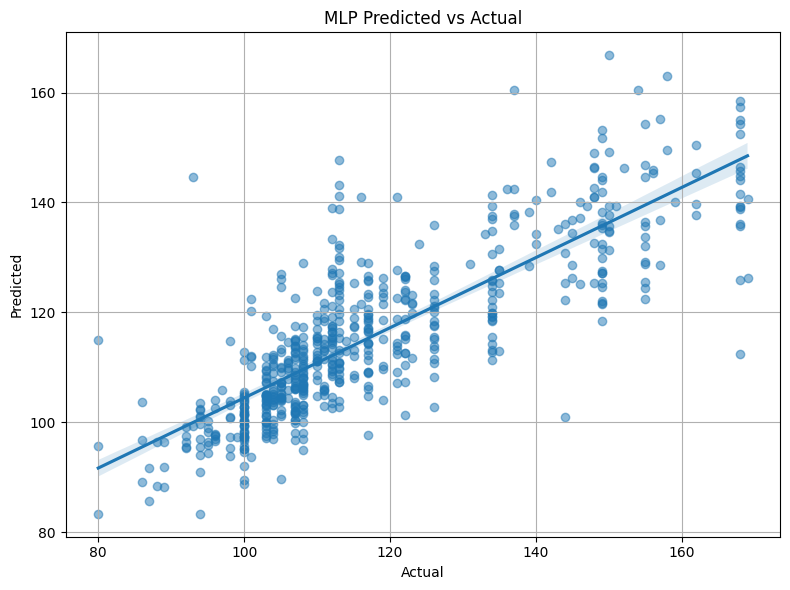

In [70]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

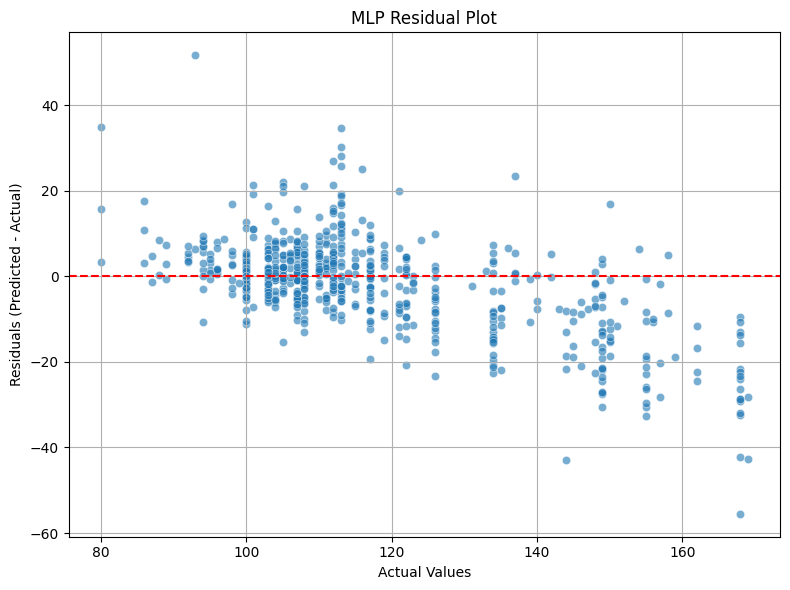

In [71]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [72]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 2524 entries, Chr1_123617 to MD
dtypes: float64(5), int64(2519)
memory usage: 47.2+ MB


In [77]:
gwas_snps = gwas_data.iloc[:, 0:2512]
gwas_snps.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_40889952,Chr20_40942681,Chr20_41470065,Chr20_43647688,Chr20_47311522,Chr20_48584494,Chr20_49775939,Chr20_50059719,Chr20_50927742,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,0,1,0,2,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,0,1,0,2,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,1,0,0,1,0,2,2,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,2,0,0,0,0
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,2,0,0,0,0


In [78]:
gwas_snps_dupe = gwas_data.iloc[:, 0:2512]
gwas_snps_dupe.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_40889952,Chr20_40942681,Chr20_41470065,Chr20_43647688,Chr20_47311522,Chr20_48584494,Chr20_49775939,Chr20_50059719,Chr20_50927742,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,0,1,0,2,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,0,1,0,2,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,1,0,0,1,0,2,2,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,2,0,0,0,0
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,2,0,0,0,0


In [79]:
gwas_y = gwas_data.iloc[:, 2523:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [80]:
X_tensor = torch.tensor(gwas_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [81]:
print(X_tensor.shape)

torch.Size([2450, 2512])


In [82]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [83]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 14:38:25,188] A new study created in memory with name: no-name-ad69ef41-e6b9-4d49-9750-d4b8e3175471
[I 2025-05-26 14:38:33,789] Trial 0 finished with value: 362.0333557128906 and parameters: {'hidden_size1': 200, 'dropout1': 0.09463023394659949, 'lr': 0.0006679150535186903, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0003403709411566746, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.043539736792312496}. Best is trial 0 with value: 362.0333557128906.
[I 2025-05-26 14:38:36,103] Trial 1 finished with value: 12841.6435546875 and parameters: {'hidden_size1': 100, 'dropout1': 0.04224005740331931, 'lr': 0.00021258697124322516, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 2.1872641486966597e-05, 'n_layers': 1}. Best is trial 0 with value: 362.0333557128906.
[I 2025-05-26 14:38:36,587] Trial 2 finished with value: 403.3211669921875 and parameters: {'hidden_size1': 200, 'dropout1': 0.0505460497218111, 'lr': 0.0024785403879303944, 'batc

Early stopping at epoch 20


[I 2025-05-26 14:38:37,900] Trial 3 finished with value: 406.9199523925781 and parameters: {'hidden_size1': 200, 'dropout1': 0.07095603297775734, 'lr': 0.0009778265571814316, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0004425743991365692, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 362.0333557128906.


Early stopping at epoch 16


[I 2025-05-26 14:38:38,856] Trial 4 finished with value: 342.614990234375 and parameters: {'hidden_size1': 200, 'dropout1': 0.016841417496558028, 'lr': 0.00010631757915269831, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 3.4792091197128335e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 4 with value: 342.614990234375.


...

Early stopping at epoch 66


[I 2025-05-26 14:40:11,663] Trial 48 finished with value: 332.42352294921875 and parameters: {'hidden_size1': 300, 'dropout1': 0.03960405828473974, 'lr': 0.007196729921774379, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0009392048526874249, 'n_layers': 1}. Best is trial 37 with value: 325.3998718261719.


Early stopping at epoch 47


[I 2025-05-26 14:40:12,896] Trial 49 finished with value: 422.7805480957031 and parameters: {'hidden_size1': 200, 'dropout1': 0.05325803586377317, 'lr': 0.0022522119780771883, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0001227610214358129, 'n_layers': 1}. Best is trial 37 with value: 325.3998718261719.


Early stopping at epoch 18
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.037988897796651155, 'lr': 0.005146421511794984, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0003146776843923298, 'n_layers': 1}


In [85]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top1_best_model_onlysnps_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 19 for fold 1
Fold 1 validation loss: 325.9171
Training fold 2
Early stopping at epoch 20 for fold 2
Fold 2 validation loss: 288.2805
Training fold 3
Early stopping at epoch 19 for fold 3
Fold 3 validation loss: 350.2053
Training fold 4
Early stopping at epoch 20 for fold 4
Fold 4 validation loss: 333.3872
Training fold 5
Early stopping at epoch 22 for fold 5
Fold 5 validation loss: 339.1551
Training fold 6
Early stopping at epoch 17 for fold 6
Fold 6 validation loss: 337.6481
Training fold 7
Early stopping at epoch 24 for fold 7
Fold 7 validation loss: 311.4507
Training fold 8
Early stopping at epoch 17 for fold 8
Fold 8 validation loss: 337.2824
Training fold 9
Early stopping at epoch 17 for fold 9
Fold 9 validation loss: 307.4159
Training fold 10
Early stopping at epoch 20 for fold 10
Fold 10 validation loss: 382.0581

Average validation loss across all folds: 331.2800
Checkpoint saved as 'gwas_top1_best_model_onlysnps_mlp_md.pth'.


In [86]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [87]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [88]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [89]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [90]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [91]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 389.0585
RMSE: 19.7246
MAE: 15.5603
R2: -0.0412
Holdout_Loss: 389.0585


In [92]:
pickle.dump(best_mlp_model, open("gwas_top1_best_model_onlysnps_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

## Top 5% SNPs

### All covariates

In [93]:
gwas_data = pd.read_pickle("pickle_files/GWAS_top5percent_md_data.pkl")
gwas_data.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,1,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s101,0,0,0,0,0,0,0,1,1,1,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
s1014,0,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


In [94]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 12573 entries, Chr1_123323 to MD
dtypes: float64(5), int64(12568)
memory usage: 235.0+ MB


In [95]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [97]:
gwas_all= gwas_data.drop(['MD'], axis=1)
gwas_all.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,1,0,0,0,0,0,0,0,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,0,1,1,1,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


In [98]:
gwas_all_dupe= gwas_data.drop(['MD'], axis=1)
gwas_all_dupe.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,1,0,0,0,0,0,0,0,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,0,1,1,1,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


In [99]:
X_tensor = torch.tensor(gwas_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [100]:
print(X_tensor.shape)

torch.Size([2450, 12572])


In [101]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [102]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 14:45:54,480] A new study created in memory with name: no-name-a171d85f-e504-475b-9fbf-b2a421abf711
[I 2025-05-26 14:45:58,837] Trial 0 finished with value: 230.98692321777344 and parameters: {'hidden_size1': 300, 'dropout1': 0.08517358810076857, 'lr': 0.0010338092519168098, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.2614020788094538e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 230.98692321777344.


Early stopping at epoch 51


[I 2025-05-26 14:46:03,861] Trial 1 finished with value: 268.49859619140625 and parameters: {'hidden_size1': 200, 'dropout1': 0.08192361446050345, 'lr': 0.0012768842237857808, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0006474826799216018, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout2': 0.016810657894983122}. Best is trial 0 with value: 230.98692321777344.
[I 2025-05-26 14:46:06,503] Trial 2 finished with value: 10198.828125 and parameters: {'hidden_size1': 100, 'dropout1': 0.03728108992577099, 'lr': 0.00032464657879945703, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 3.446866647233935e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 230.98692321777344.
[I 2025-05-26 14:46:10,859] Trial 3 finished with value: 7241.21826171875 and parameters: {'hidden_size1': 100, 'dropout1': 0.08362992212653614, 'lr': 0.00024352236732244091, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0001334727394035591, 'n_layers': 2, 'hidden

Early stopping at epoch 39


[I 2025-05-26 14:46:14,023] Trial 5 finished with value: 380.3571472167969 and parameters: {'hidden_size1': 200, 'dropout1': 0.02221259965543028, 'lr': 0.000784145386829281, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0006588144188965053, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout2': 0.03822840024670325}. Best is trial 4 with value: 226.3191375732422.


...

Early stopping at epoch 71


[I 2025-05-26 14:47:53,440] Trial 48 finished with value: 293.79815673828125 and parameters: {'hidden_size1': 200, 'dropout1': 0.04702421327736718, 'lr': 0.00022422900899092248, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 4.5289642560811674e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 45 with value: 156.11984252929688.


Early stopping at epoch 22


[I 2025-05-26 14:47:57,755] Trial 49 finished with value: 655.5734252929688 and parameters: {'hidden_size1': 200, 'dropout1': 0.02444365720310761, 'lr': 0.0005177536584373656, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 1.5347891733580973e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 45 with value: 156.11984252929688.


Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.0327834797725244, 'lr': 0.0004771310336004654, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.00014783641490255511, 'n_layers': 2, 'hidden_size2': 150}


In [104]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top5_best_model_allfeats_mlp_md_test.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 16 for fold 1
Fold 1 validation loss: 274.2907
Training fold 2
Early stopping at epoch 15 for fold 2
Fold 2 validation loss: 243.5868
Training fold 3
Early stopping at epoch 15 for fold 3
Fold 3 validation loss: 304.1851
Training fold 4
Early stopping at epoch 13 for fold 4
Fold 4 validation loss: 270.5755
Training fold 5
Early stopping at epoch 15 for fold 5
Fold 5 validation loss: 279.0157
Training fold 6
Early stopping at epoch 16 for fold 6
Fold 6 validation loss: 290.1124
Training fold 7
Early stopping at epoch 17 for fold 7
Fold 7 validation loss: 251.8972
Training fold 8
Early stopping at epoch 63 for fold 8
Fold 8 validation loss: 205.5697
Training fold 9
Early stopping at epoch 13 for fold 9
Fold 9 validation loss: 289.5221
Training fold 10
Fold 10 validation loss: 206.1767

Average validation loss across all folds: 261.4932
Checkpoint saved as 'gwas_top5_best_model_allfeats_mlp_md_test.pth'.


In [105]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [106]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [107]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [108]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [109]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [110]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 12572 entries, Chr1_123323 to landrace
dtypes: float64(4), int64(12568)
memory usage: 58.8+ MB


In [111]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [112]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 240.3488
RMSE: 15.5032
MAE: 11.7828
R2: 0.3568
Holdout_Loss: 240.3488


In [113]:
pickle.dump(best_mlp_model, open("gwas_top5_best_model_allfeats_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 121.704315
1 148.0 149.34195
2 117.0 120.237045
3 121.0 134.5535
4 119.0 122.681694
5 94.0 102.335045


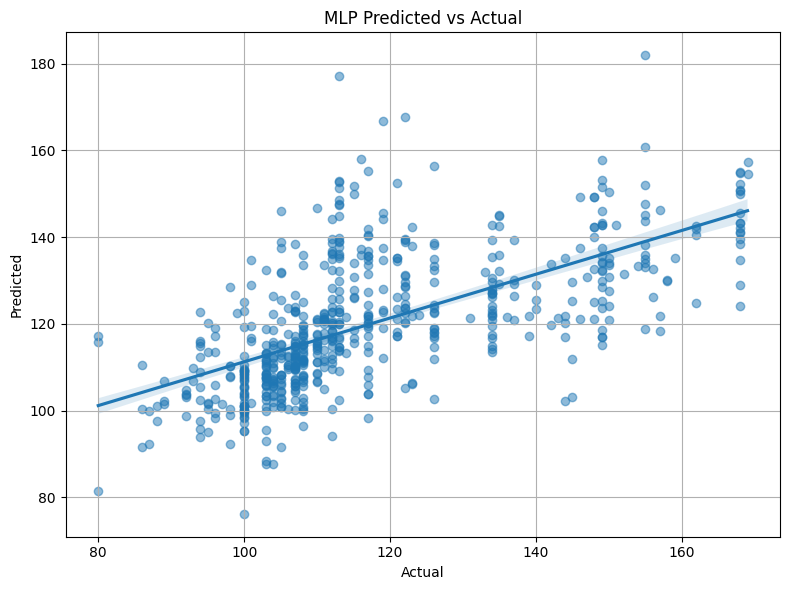

In [114]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

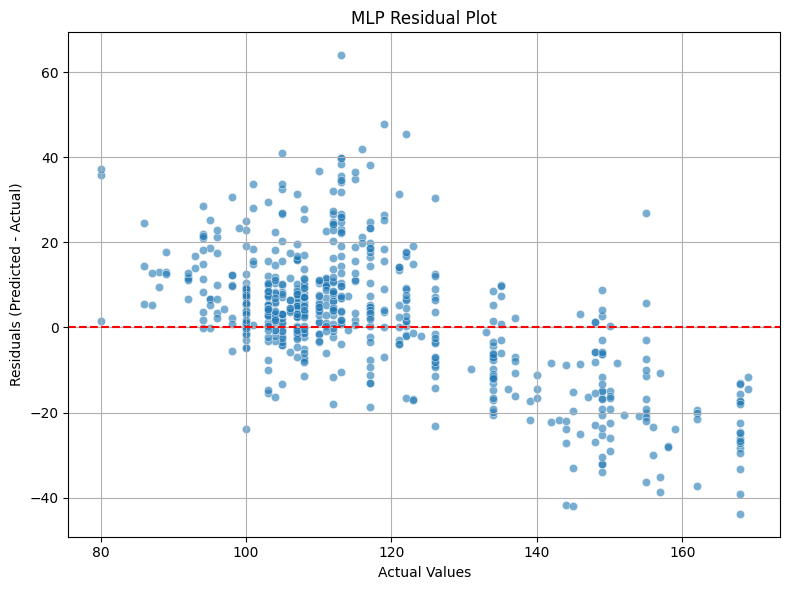

In [115]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [116]:
gwas_loc= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_52212855,Chr20_52247340,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
s100,1,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,0,1,1,1,...,0,1,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [117]:
gwas_loc_dupe= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc_dupe.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_52212855,Chr20_52247340,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
s100,1,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,0,1,1,1,...,0,1,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [118]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 12568 entries, Chr1_123323 to landrace
dtypes: int64(12568)
memory usage: 234.9+ MB


In [119]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [120]:
X_tensor = torch.tensor(gwas_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [121]:
print(X_tensor.shape)

torch.Size([2450, 12568])


In [122]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [141]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 15:09:03,249] A new study created in memory with name: no-name-0d49d858-10cb-411a-aa84-a491cee2da12
[I 2025-05-26 15:09:04,352] Trial 0 finished with value: 367.1838684082031 and parameters: {'hidden_size1': 100, 'dropout1': 0.015539857937033413, 'lr': 0.0002530497507127906, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 2.2275991209132323e-05, 'n_layers': 1}. Best is trial 0 with value: 367.1838684082031.


Early stopping at epoch 16


[I 2025-05-26 15:09:06,797] Trial 1 finished with value: 12147.181640625 and parameters: {'hidden_size1': 200, 'dropout1': 0.08509686393571146, 'lr': 0.0001771483349143225, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0005234836006031594, 'n_layers': 1}. Best is trial 0 with value: 367.1838684082031.
[I 2025-05-26 15:09:08,282] Trial 2 finished with value: 1647.4327392578125 and parameters: {'hidden_size1': 300, 'dropout1': 0.08028027856503527, 'lr': 0.00644856595496882, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.009180248408203438, 'n_layers': 1}. Best is trial 0 with value: 367.1838684082031.


Early stopping at epoch 21


[I 2025-05-26 15:09:12,515] Trial 3 finished with value: 311.653564453125 and parameters: {'hidden_size1': 100, 'dropout1': 0.012039575412231012, 'lr': 0.004174067301426282, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0002483216457944266, 'n_layers': 1}. Best is trial 3 with value: 311.653564453125.


...

Early stopping at epoch 87


[I 2025-05-26 15:11:41,237] Trial 48 finished with value: 335.99981689453125 and parameters: {'hidden_size1': 300, 'dropout1': 0.07119561250471378, 'lr': 0.00601505328786861, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.530737644781833e-05, 'n_layers': 1}. Best is trial 47 with value: 307.4647216796875.


Early stopping at epoch 30


[I 2025-05-26 15:11:46,535] Trial 49 finished with value: 308.6923522949219 and parameters: {'hidden_size1': 300, 'dropout1': 0.051827289522321046, 'lr': 0.002877486882374634, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0031061013611661656, 'n_layers': 1}. Best is trial 47 with value: 307.4647216796875.


Early stopping at epoch 79
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.07188241124237926, 'lr': 0.0028549864267194023, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 3.909537776631272e-05, 'n_layers': 1}


In [142]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top5_best_model_onlyloc_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 20 for fold 1
Fold 1 validation loss: 308.2426
Training fold 2
Early stopping at epoch 20 for fold 2
Fold 2 validation loss: 274.9027
Training fold 3
Early stopping at epoch 20 for fold 3
Fold 3 validation loss: 343.3172
Training fold 4
Early stopping at epoch 21 for fold 4
Fold 4 validation loss: 318.4094
Training fold 5
Early stopping at epoch 22 for fold 5
Fold 5 validation loss: 318.7552
Training fold 6
Early stopping at epoch 20 for fold 6
Fold 6 validation loss: 315.2659
Training fold 7
Early stopping at epoch 19 for fold 7
Fold 7 validation loss: 291.8861
Training fold 8
Early stopping at epoch 20 for fold 8
Fold 8 validation loss: 314.1032
Training fold 9
Early stopping at epoch 17 for fold 9
Fold 9 validation loss: 300.8001
Training fold 10
Early stopping at epoch 22 for fold 10
Fold 10 validation loss: 382.7418

Average validation loss across all folds: 316.8424
Checkpoint saved as 'gwas_top5_best_model_onlyloc_mlp_md.pth'.


In [143]:
best_mlp_model

Sequential(
  (0): Linear(in_features=12568, out_features=300, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.07188241124237926, inplace=False)
  (3): Linear(in_features=300, out_features=1, bias=True)
)

In [144]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [145]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [146]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [147]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 12568 entries, Chr1_123323 to landrace
dtypes: int64(12568)
memory usage: 58.8+ MB


In [148]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [149]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 379.6626
RMSE: 19.4849
MAE: 15.3895
R2: -0.0161
Holdout_Loss: 379.6627


In [150]:
pickle.dump(best_mlp_model, open("'gwas_top5_best_model_onlyloc_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 129.74919
1 148.0 110.571335
2 117.0 108.33871
3 121.0 131.75786
4 119.0 130.42744
5 94.0 105.01717


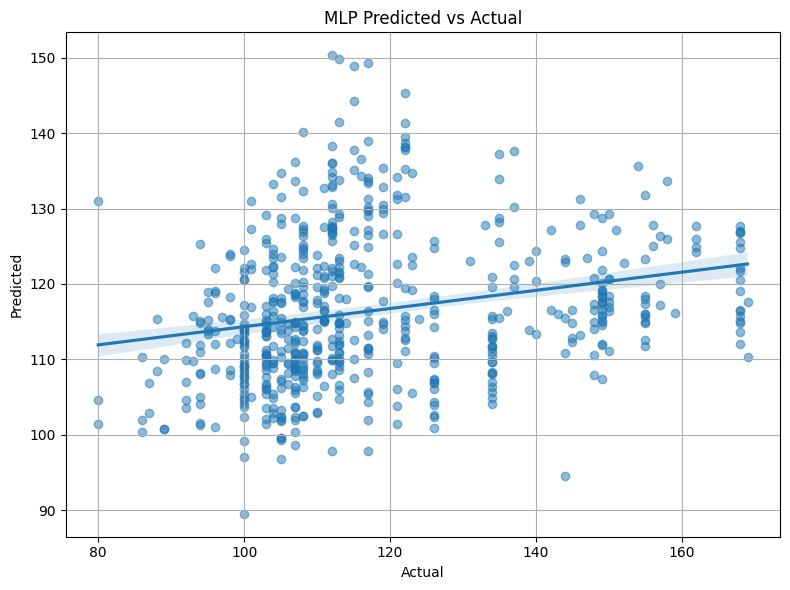

In [151]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

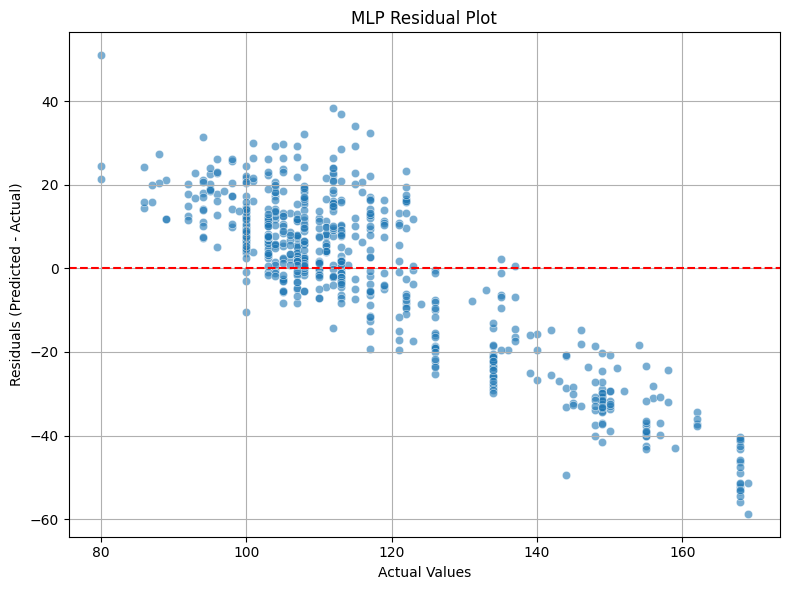

In [152]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [153]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 12573 entries, Chr1_123323 to MD
dtypes: float64(5), int64(12568)
memory usage: 235.0+ MB


In [154]:
gwas_snps = gwas_data.iloc[:, 0:12561]
gwas_snps.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_50433300,Chr20_50674780,Chr20_50927742,Chr20_51166518,Chr20_51479710,Chr20_51666590,Chr20_51666785,Chr20_52212855,Chr20_52247340,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,0,2,0,2,0,0,0,0,1,0
s100,1,1,0,0,0,0,0,0,0,0,...,0,2,0,2,0,0,0,0,1,0
s101,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,1,1,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [155]:
gwas_snps_dupe = gwas_data.iloc[:, 0:12561]
gwas_snps_dupe.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_50433300,Chr20_50674780,Chr20_50927742,Chr20_51166518,Chr20_51479710,Chr20_51666590,Chr20_51666785,Chr20_52212855,Chr20_52247340,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,0,2,0,2,0,0,0,0,1,0
s100,1,1,0,0,0,0,0,0,0,0,...,0,2,0,2,0,0,0,0,1,0
s101,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,1,1,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [156]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [157]:
X_tensor = torch.tensor(gwas_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [158]:
print(X_tensor.shape)

torch.Size([2450, 12561])


In [159]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [160]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 15:13:26,185] A new study created in memory with name: no-name-949d668b-6185-4d12-98a8-99501b4fc4a4
[I 2025-05-26 15:13:26,790] Trial 0 finished with value: 386.19403076171875 and parameters: {'hidden_size1': 200, 'dropout1': 0.07556645062069929, 'lr': 0.0003569976402590028, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 2.6401758743286285e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 386.19403076171875.


Early stopping at epoch 21


[I 2025-05-26 15:13:28,544] Trial 1 finished with value: 365.41650390625 and parameters: {'hidden_size1': 100, 'dropout1': 0.07274707621524179, 'lr': 0.0005004561211734742, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.00867252988956414, 'n_layers': 1}. Best is trial 1 with value: 365.41650390625.


Early stopping at epoch 24


[I 2025-05-26 15:13:31,011] Trial 2 finished with value: 355.2225646972656 and parameters: {'hidden_size1': 200, 'dropout1': 0.06367183238457226, 'lr': 0.0015648969865939173, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 1.4372842400755921e-05, 'n_layers': 1}. Best is trial 2 with value: 355.2225646972656.
[I 2025-05-26 15:13:32,014] Trial 3 finished with value: 334.24969482421875 and parameters: {'hidden_size1': 100, 'dropout1': 0.0705390991648579, 'lr': 0.0038998655588684955, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.00011176787128850706, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.08596624271653963}. Best is trial 3 with value: 334.24969482421875.


...

Early stopping at epoch 91


[I 2025-05-26 15:15:00,235] Trial 47 finished with value: 401.9184875488281 and parameters: {'hidden_size1': 200, 'dropout1': 0.0584587577663082, 'lr': 0.001110761222532784, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 3.24108597942059e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 32 with value: 314.79522705078125.
[I 2025-05-26 15:15:02,110] Trial 48 finished with value: 316.1986389160156 and parameters: {'hidden_size1': 200, 'dropout1': 0.09919566464549998, 'lr': 0.007169416562788066, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.00034456220720290026, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 32 with value: 314.79522705078125.


Early stopping at epoch 69


[I 2025-05-26 15:15:03,070] Trial 49 finished with value: 390.6031188964844 and parameters: {'hidden_size1': 200, 'dropout1': 0.05061185815716447, 'lr': 0.0020001530320385703, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.002171285426545723, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 32 with value: 314.79522705078125.


Early stopping at epoch 11
Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.09249869359674023, 'lr': 0.003677715929114386, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 3.071889790223545e-05, 'n_layers': 2, 'hidden_size2': 150}


In [161]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top5_best_model_onlysnps_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 25 for fold 1
Fold 1 validation loss: 313.1756
Training fold 2
Early stopping at epoch 24 for fold 2
Fold 2 validation loss: 278.9695
Training fold 3
Early stopping at epoch 28 for fold 3
Fold 3 validation loss: 348.5611
Training fold 4
Early stopping at epoch 27 for fold 4
Fold 4 validation loss: 327.1668
Training fold 5
Early stopping at epoch 28 for fold 5
Fold 5 validation loss: 329.8384
Training fold 6
Early stopping at epoch 24 for fold 6
Fold 6 validation loss: 321.8788
Training fold 7
Early stopping at epoch 28 for fold 7
Fold 7 validation loss: 302.8594
Training fold 8
Early stopping at epoch 23 for fold 8
Fold 8 validation loss: 321.1778
Training fold 9
Early stopping at epoch 24 for fold 9
Fold 9 validation loss: 307.0402
Training fold 10
Early stopping at epoch 21 for fold 10
Fold 10 validation loss: 390.6961

Average validation loss across all folds: 324.1364
Checkpoint saved as 'gwas_top5_best_model_onlysnps_mlp_md.pth'.


In [162]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [163]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [164]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [165]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [166]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 384.9540
RMSE: 19.6202
MAE: 15.5269
R2: -0.0302
Holdout_Loss: 384.9540


In [167]:
pickle.dump(best_mlp_model, open("gwas_top5_best_model_onlysnps_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 128.98418
1 148.0 109.907005
2 117.0 106.7813
3 121.0 128.09715
4 119.0 128.09715
5 94.0 105.21069


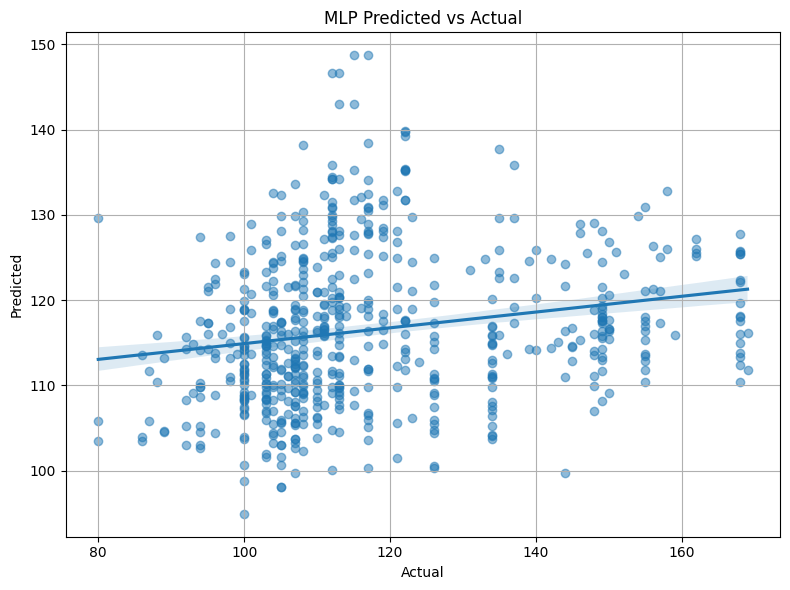

In [168]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

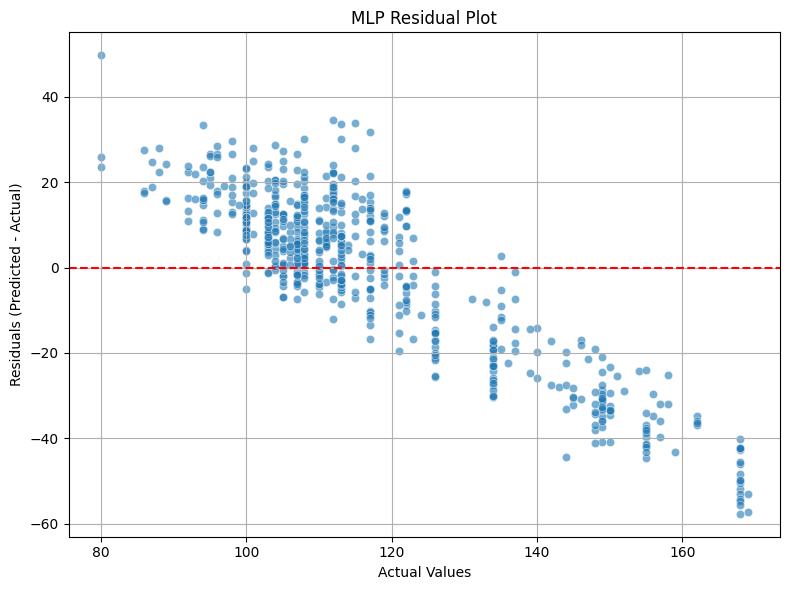

In [169]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

## Top 10% SNPs

In [170]:
gwas_data = pd.read_pickle("pickle_files/GWAS_top10percent_md_data.pkl")
gwas_data.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,0,1,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s101,0,0,0,1,0,1,0,0,0,0,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
s1014,0,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


In [171]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 25135 entries, Chr1_123323 to MD
dtypes: float64(5), int64(25130)
memory usage: 469.8+ MB


In [172]:
gwas_y = gwas_data.iloc[:, 25134:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


### All covariates

In [173]:
gwas_all= gwas_data.drop(['MD'], axis=1)
gwas_all.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,1,0,0,0,0,0,0,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


In [174]:
gwas_all_dupe= gwas_data.drop(['MD'], axis=1)
gwas_all_dupe.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,1,0,0,0,0,0,0,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


In [175]:
X_tensor = torch.tensor(gwas_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [176]:
print(X_tensor.shape)

torch.Size([2450, 25134])


In [177]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [178]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 15:17:55,904] A new study created in memory with name: no-name-d721d411-2e2f-4b4d-bfd1-ad5d81aa9874
[I 2025-05-26 15:17:57,220] Trial 0 finished with value: 303.079833984375 and parameters: {'hidden_size1': 300, 'dropout1': 0.09698526764811378, 'lr': 0.00022247556924949644, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.001440747903166821, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout2': 0.015492413035892796}. Best is trial 0 with value: 303.079833984375.


Early stopping at epoch 35


[I 2025-05-26 15:17:58,382] Trial 1 finished with value: 356.9299011230469 and parameters: {'hidden_size1': 300, 'dropout1': 0.06715184818687568, 'lr': 0.0009934688612508805, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.001556237430217213, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 303.079833984375.


Early stopping at epoch 17


[I 2025-05-26 15:18:01,544] Trial 2 finished with value: 12642.2998046875 and parameters: {'hidden_size1': 200, 'dropout1': 0.050591472597961186, 'lr': 0.00023690730079852144, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.00010638942842514638, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.09832876917237732}. Best is trial 0 with value: 303.079833984375.
[I 2025-05-26 15:18:06,403] Trial 3 finished with value: 6049.134765625 and parameters: {'hidden_size1': 300, 'dropout1': 0.04620647862461384, 'lr': 0.00026491813254072395, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.000990193788403768, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 303.079833984375.
[I 2025-05-26 15:18:07,777] Trial 4 finished with value: 282.92913818359375 and parameters: {'hidden_size1': 100, 'dropout1': 0.09947788710033068, 'lr': 0.0008289702403399818, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0009464156564667301, 'n_layers': 2, 'hidden_s

...

Early stopping at epoch 34


[I 2025-05-26 15:21:47,513] Trial 46 finished with value: 231.6605224609375 and parameters: {'hidden_size1': 200, 'dropout1': 0.010010504549946682, 'lr': 0.0038029988182969273, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.003228394984660607, 'n_layers': 1}. Best is trial 10 with value: 224.5726776123047.
[I 2025-05-26 15:21:50,703] Trial 47 finished with value: 231.4953155517578 and parameters: {'hidden_size1': 200, 'dropout1': 0.02733757017237394, 'lr': 0.007990176757857645, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.006730589972734102, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout2': 0.033071161974492114}. Best is trial 10 with value: 224.5726776123047.


Early stopping at epoch 62


[I 2025-05-26 15:21:57,594] Trial 48 finished with value: 319.6766052246094 and parameters: {'hidden_size1': 100, 'dropout1': 0.014106275433211482, 'lr': 0.0004144513779771999, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0016292731292274396, 'n_layers': 1}. Best is trial 10 with value: 224.5726776123047.
[I 2025-05-26 15:22:00,343] Trial 49 finished with value: 685.8762817382812 and parameters: {'hidden_size1': 200, 'dropout1': 0.0199667795397852, 'lr': 0.0045749916842236504, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0025125523381866344, 'n_layers': 1}. Best is trial 10 with value: 224.5726776123047.


Early stopping at epoch 27
Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.012611037237755668, 'lr': 0.008859969842408355, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.009705006296179914, 'n_layers': 1}


In [180]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top10_best_model_allfeats_mlp_md_test.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 24 for fold 1
Fold 1 validation loss: 224.1187
Training fold 2
Early stopping at epoch 21 for fold 2
Fold 2 validation loss: 196.6125
Training fold 3
Early stopping at epoch 27 for fold 3
Fold 3 validation loss: 232.6333
Training fold 4
Early stopping at epoch 16 for fold 4
Fold 4 validation loss: 225.1618
Training fold 5
Early stopping at epoch 25 for fold 5
Fold 5 validation loss: 248.6754
Training fold 6
Early stopping at epoch 24 for fold 6
Fold 6 validation loss: 240.9163
Training fold 7
Early stopping at epoch 29 for fold 7
Fold 7 validation loss: 198.7323
Training fold 8
Early stopping at epoch 20 for fold 8
Fold 8 validation loss: 209.6092
Training fold 9
Early stopping at epoch 14 for fold 9
Fold 9 validation loss: 254.5743
Training fold 10
Early stopping at epoch 30 for fold 10
Fold 10 validation loss: 256.9064

Average validation loss across all folds: 228.7940
Checkpoint saved as 'gwas_top10_best_model_allfeats_mlp_md_test.pth'.


In [181]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [182]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [183]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [184]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [185]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [186]:
X_holdout.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,1,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [187]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [188]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 268.8029
RMSE: 16.3952
MAE: 13.1272
R2: 0.2806
Holdout_Loss: 268.8029


In [189]:
pickle.dump(best_mlp_model, open("gwas_top10_best_model_allfeats_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 136.24957
1 148.0 140.27129
2 117.0 118.0533
3 121.0 128.56429
4 119.0 126.47222
5 94.0 99.69434


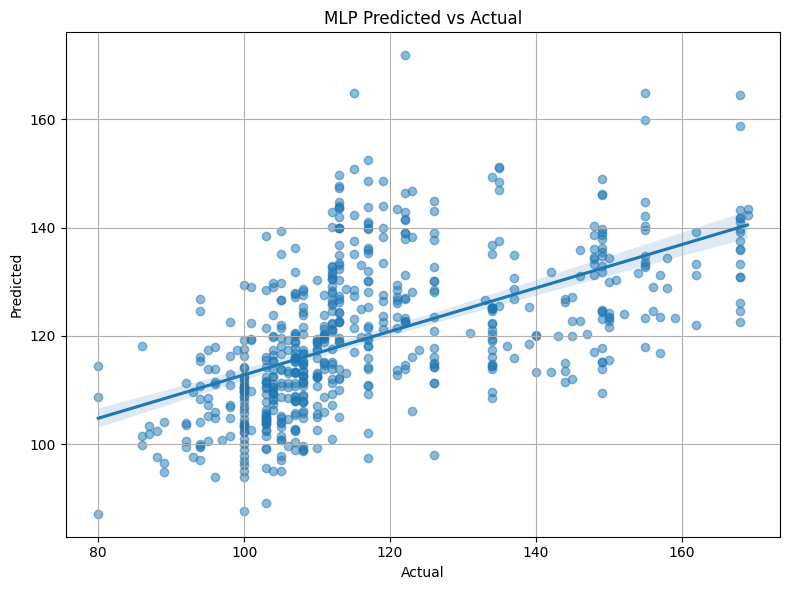

In [190]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

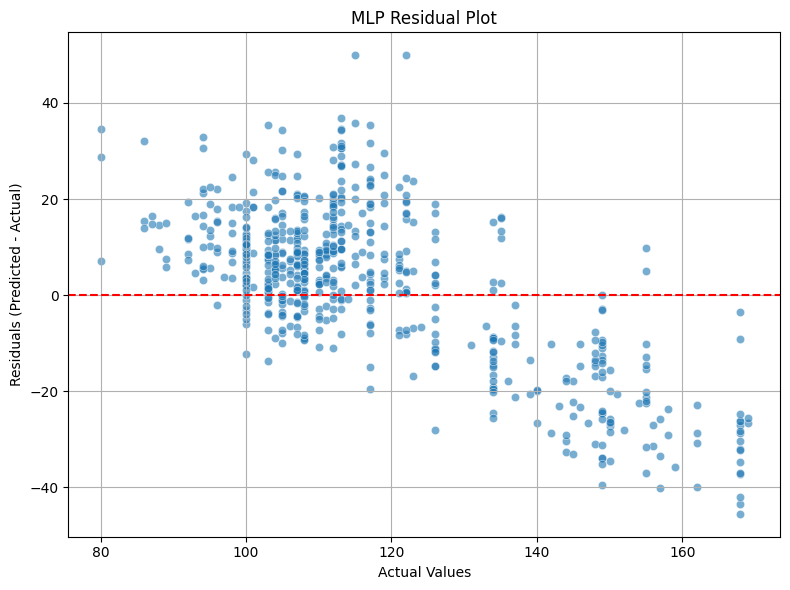

In [191]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only Location

In [192]:
gwas_loc= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_52247340,Chr20_52255532,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,1,2,0,1,0,0,0,0,0,1
s100,1,0,1,0,0,0,0,0,0,0,...,1,2,0,0,0,1,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,1,2,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [193]:
gwas_loc_dupe= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc_dupe.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_52247340,Chr20_52255532,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,1,2,0,1,0,0,0,0,0,1
s100,1,0,1,0,0,0,0,0,0,0,...,1,2,0,0,0,1,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,1,2,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [194]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 25130 entries, Chr1_123323 to landrace
dtypes: int64(25130)
memory usage: 469.7+ MB


In [195]:
gwas_y = gwas_data.iloc[:, 25134:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [196]:
X_tensor = torch.tensor(gwas_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [197]:
print(X_tensor.shape)

torch.Size([2450, 25130])


In [198]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [199]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 15:24:34,365] A new study created in memory with name: no-name-6f570794-af82-4c61-836c-434f91fd7d84
[I 2025-05-26 15:24:36,878] Trial 0 finished with value: 384.6318054199219 and parameters: {'hidden_size1': 300, 'dropout1': 0.04538530726470252, 'lr': 0.00014923208744374074, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 2.6282194569189814e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 384.6318054199219.


Early stopping at epoch 17


[I 2025-05-26 15:24:38,507] Trial 1 finished with value: 402.9130554199219 and parameters: {'hidden_size1': 200, 'dropout1': 0.036328963660856535, 'lr': 0.00023510012250618556, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 1.1440978008546323e-05, 'n_layers': 1}. Best is trial 0 with value: 384.6318054199219.


Early stopping at epoch 16


[I 2025-05-26 15:24:39,171] Trial 2 finished with value: 406.9471130371094 and parameters: {'hidden_size1': 100, 'dropout1': 0.07415374875671946, 'lr': 0.0005859386178127122, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.000222571238244941, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout2': 0.02933597432720062}. Best is trial 0 with value: 384.6318054199219.


...

Early stopping at epoch 18


[I 2025-05-26 15:26:47,464] Trial 47 finished with value: 308.4055480957031 and parameters: {'hidden_size1': 100, 'dropout1': 0.02645877284006133, 'lr': 0.0035547283685317377, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0009893169995082575, 'n_layers': 1}. Best is trial 26 with value: 307.80352783203125.
[I 2025-05-26 15:26:48,232] Trial 48 finished with value: 691.2681884765625 and parameters: {'hidden_size1': 300, 'dropout1': 0.0406037486577315, 'lr': 0.0073271885426946185, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.001737940012876159, 'n_layers': 1}. Best is trial 26 with value: 307.80352783203125.


Early stopping at epoch 21


[I 2025-05-26 15:26:51,050] Trial 49 finished with value: 2764.771240234375 and parameters: {'hidden_size1': 100, 'dropout1': 0.0306224266264423, 'lr': 0.0007366074090486616, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0009560218141604248, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 26 with value: 307.80352783203125.


Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.03100109388155071, 'lr': 0.0029234387194329143, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0045255031718791396, 'n_layers': 2, 'hidden_size2': 150}


In [200]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top10_best_model_onlyloc_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 19 for fold 1
Fold 1 validation loss: 309.8452
Training fold 2
Early stopping at epoch 20 for fold 2
Fold 2 validation loss: 280.9321
Training fold 3
Early stopping at epoch 21 for fold 3
Fold 3 validation loss: 349.7578
Training fold 4
Early stopping at epoch 25 for fold 4
Fold 4 validation loss: 322.1192
Training fold 5
Early stopping at epoch 27 for fold 5
Fold 5 validation loss: 335.6018
Training fold 6
Early stopping at epoch 21 for fold 6
Fold 6 validation loss: 318.9941
Training fold 7
Early stopping at epoch 21 for fold 7
Fold 7 validation loss: 297.2140
Training fold 8
Early stopping at epoch 24 for fold 8
Fold 8 validation loss: 324.1629
Training fold 9
Early stopping at epoch 19 for fold 9
Fold 9 validation loss: 309.5085
Training fold 10
Early stopping at epoch 24 for fold 10
Fold 10 validation loss: 386.6437

Average validation loss across all folds: 323.4779
Checkpoint saved as 'gwas_top10_best_model_onlyloc_mlp_md.pth'.


In [201]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [202]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [203]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [204]:
X_holdout.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_52247340,Chr20_52255532,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,1,2,0,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
s1019,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,1,2,0,1,0,0,0,0,0,1
s101,0,0,0,1,0,1,0,0,0,0,...,1,2,0,0,0,0,0,1,0,1


In [205]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [206]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 386.7286
RMSE: 19.6654
MAE: 15.6643
R2: -0.0350
Holdout_Loss: 386.7286


In [207]:
pickle.dump(best_mlp_model, open("gwas_top10_best_model_onlyloc_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 129.66544
1 148.0 112.6878
2 117.0 109.06117
3 121.0 131.11186
4 119.0 130.47775
5 94.0 101.257835


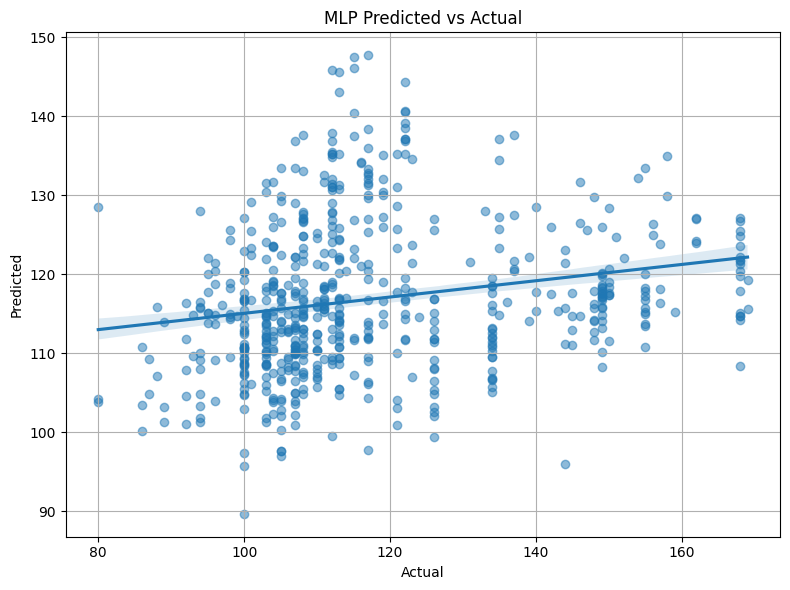

In [208]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

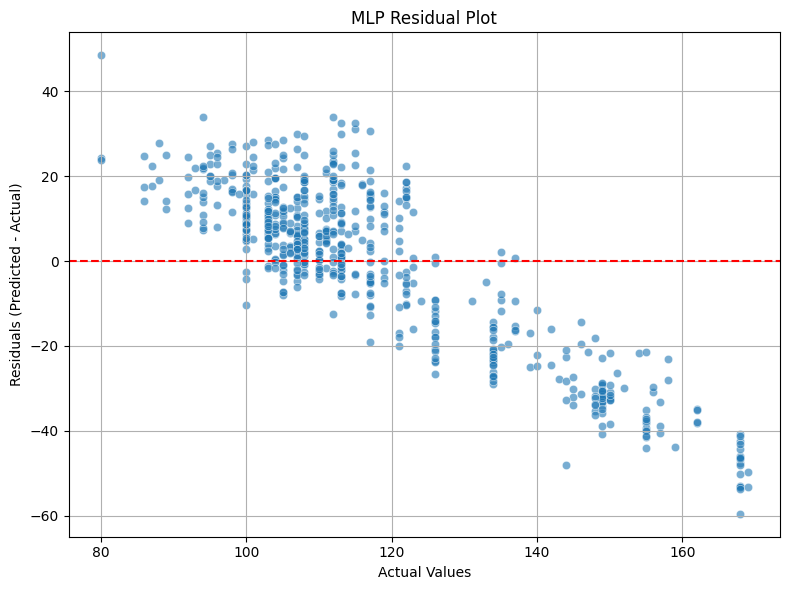

In [209]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [210]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 25135 entries, Chr1_123323 to MD
dtypes: float64(5), int64(25130)
memory usage: 469.8+ MB


In [211]:
gwas_snps = gwas_data.iloc[:, 0:25123]
gwas_snps.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_51666785,Chr20_51679540,Chr20_51888995,Chr20_51890957,Chr20_51895489,Chr20_51958004,Chr20_52212855,Chr20_52247340,Chr20_52255532,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,2,0
s100,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,2,0
s101,0,0,0,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,2,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [212]:
gwas_snps_dupe = gwas_data.iloc[:, 0:25123]
gwas_snps_dupe.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_51666785,Chr20_51679540,Chr20_51888995,Chr20_51890957,Chr20_51895489,Chr20_51958004,Chr20_52212855,Chr20_52247340,Chr20_52255532,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,2,0
s100,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,2,0
s101,0,0,0,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,2,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [213]:
gwas_y = gwas_data.iloc[:, 25134:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [214]:
X_tensor = torch.tensor(gwas_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [215]:
print(X_tensor.shape)

torch.Size([2450, 25123])


In [216]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [217]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 15:28:24,884] A new study created in memory with name: no-name-eb9f6259-e0ef-45b8-ab55-e729b61493c6
[I 2025-05-26 15:28:25,586] Trial 0 finished with value: 393.3748779296875 and parameters: {'hidden_size1': 200, 'dropout1': 0.029934073465016697, 'lr': 0.0002140767156049231, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.00036739617437408064, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 393.3748779296875.


Early stopping at epoch 13


[I 2025-05-26 15:28:26,622] Trial 1 finished with value: 575.0719604492188 and parameters: {'hidden_size1': 100, 'dropout1': 0.0849870275265831, 'lr': 0.0015061512616718975, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0025802236041353563, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout2': 0.051978843303838236}. Best is trial 0 with value: 393.3748779296875.


Early stopping at epoch 20


[I 2025-05-26 15:28:28,622] Trial 2 finished with value: 406.10772705078125 and parameters: {'hidden_size1': 300, 'dropout1': 0.06842105978318803, 'lr': 0.0006536394196943841, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.6172516506364714e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.017153060390617425}. Best is trial 0 with value: 393.3748779296875.


...

Early stopping at epoch 12


[I 2025-05-26 15:30:28,013] Trial 48 finished with value: 311.70538330078125 and parameters: {'hidden_size1': 100, 'dropout1': 0.019238532873763092, 'lr': 0.0025698196807042023, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 5.4413466350589184e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 26 with value: 310.75201416015625.


Early stopping at epoch 89


[I 2025-05-26 15:30:32,362] Trial 49 finished with value: 324.37939453125 and parameters: {'hidden_size1': 100, 'dropout1': 0.016889007836693042, 'lr': 0.0011407197446893862, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 4.970161676607701e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 26 with value: 310.75201416015625.


Best hyperparameters: {'hidden_size1': 100, 'dropout1': 0.03424266114150523, 'lr': 0.003321079376702817, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 2.6361403844523276e-05, 'n_layers': 2, 'hidden_size2': 50}


In [218]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top10_best_model_onlysnps_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 21 for fold 1
Fold 1 validation loss: 311.7046
Training fold 2
Early stopping at epoch 26 for fold 2
Fold 2 validation loss: 278.8502
Training fold 3
Early stopping at epoch 23 for fold 3
Fold 3 validation loss: 351.3990
Training fold 4
Early stopping at epoch 27 for fold 4
Fold 4 validation loss: 323.6454
Training fold 5
Early stopping at epoch 27 for fold 5
Fold 5 validation loss: 336.0907
Training fold 6
Early stopping at epoch 25 for fold 6
Fold 6 validation loss: 321.4912
Training fold 7
Early stopping at epoch 26 for fold 7
Fold 7 validation loss: 296.5230
Training fold 8
Early stopping at epoch 23 for fold 8
Fold 8 validation loss: 321.8649
Training fold 9
Early stopping at epoch 23 for fold 9
Fold 9 validation loss: 305.1599
Training fold 10
Early stopping at epoch 25 for fold 10
Fold 10 validation loss: 385.3681

Average validation loss across all folds: 323.2097
Checkpoint saved as 'gwas_top10_best_model_onlysnps_mlp_md.pth'.


In [219]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [220]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [221]:
# Ensure both training and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [222]:
X_holdout.head()

,Chr1_123323,Chr1_123346,Chr1_123617,Chr1_128719,Chr1_155648,Chr1_209166,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,...,Chr20_51666785,Chr20_51679540,Chr20_51888995,Chr20_51890957,Chr20_51895489,Chr20_51958004,Chr20_52212855,Chr20_52247340,Chr20_52255532,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,2,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s1019,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
s101,0,0,0,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,2,0
s101,0,0,0,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,2,0


In [223]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [224]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 393.9923
RMSE: 19.8492
MAE: 15.9488
R2: -0.0544
Holdout_Loss: 393.9924


In [225]:
pickle.dump(best_mlp_model, open("gwas_top10_best_model_onlysnps_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 129.30045
1 148.0 111.30182
2 117.0 110.1234
3 121.0 128.07886
4 119.0 128.07886
5 94.0 103.62422


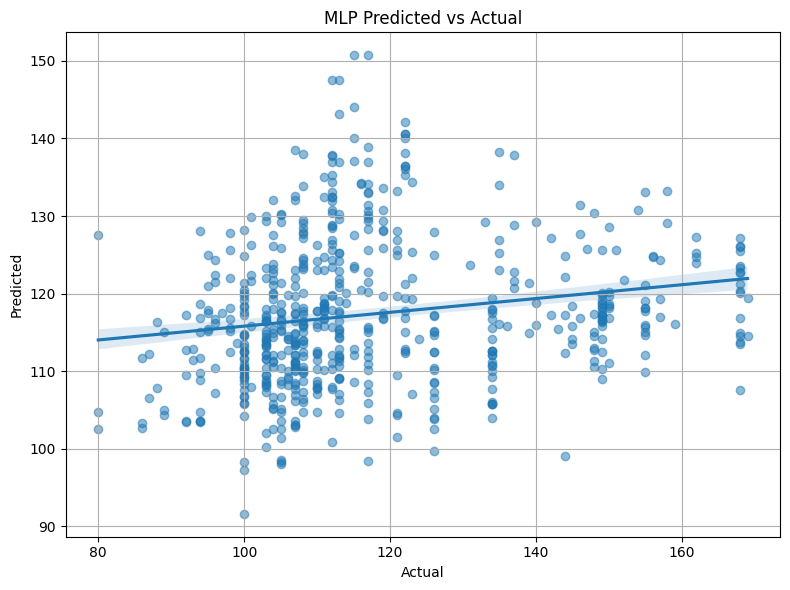

In [226]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

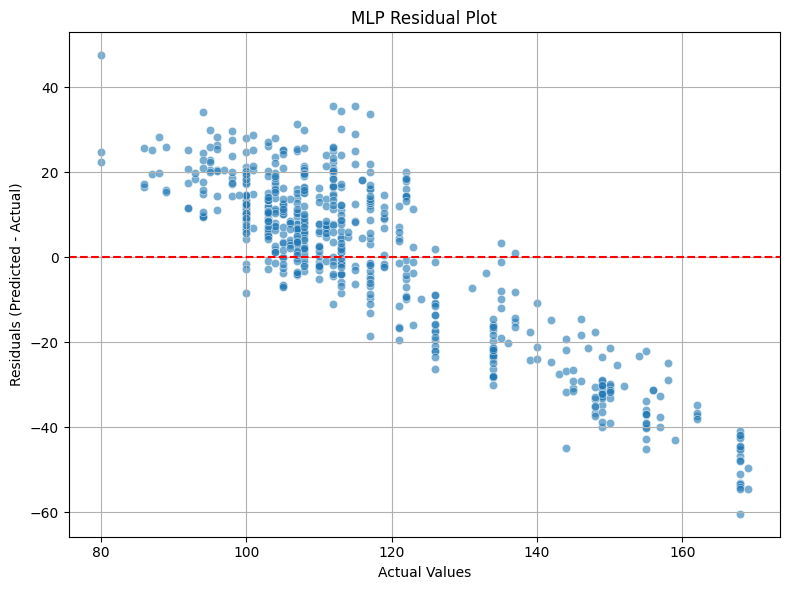

In [227]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

# LASSO regression 

In [381]:
fs_data = pd.read_pickle("pickle_files/fs_md_lasso_training_data_new.pkl")

In [382]:
fs_data.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,2,1,0,2,0,1,2,0,2,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,0,2,0,2,0,2,0,0,2,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,2,0,2,0,2,0,0,2,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,0,0,0,0,0,2,2,0,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


### All features

In [383]:
X_all = fs_data.drop("MD", axis=1).values
y_all = fs_data["MD"].values

In [384]:
X_dupe = fs_data.drop("MD", axis=1)
X_dupe.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,2,1,0,2,0,1,2,0,2,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1
s1019,0,0,0,0,0,2,2,0,0,0,...,7.34667,61.0,4.60000,0,0,1,0,0,0,1


In [385]:
X_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [386]:
print(X_tensor.shape)

torch.Size([2450, 131])


In [387]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [388]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 16:18:02,916] A new study created in memory with name: no-name-4061481b-72cb-4539-99ec-8f06ee9f2146
[I 2025-05-26 16:18:05,094] Trial 0 finished with value: 164.00552368164062 and parameters: {'hidden_size1': 300, 'dropout1': 0.06532466436396521, 'lr': 0.00025993357622989286, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.002453409633501223, 'n_layers': 1}. Best is trial 0 with value: 164.00552368164062.


Early stopping at epoch 86


[I 2025-05-26 16:18:06,921] Trial 1 finished with value: 158.7359619140625 and parameters: {'hidden_size1': 300, 'dropout1': 0.0726934228545262, 'lr': 0.0005004612851674196, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.00045136831177812904, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.06862861300878793}. Best is trial 1 with value: 158.7359619140625.


Early stopping at epoch 36


[I 2025-05-26 16:18:07,492] Trial 2 finished with value: 298.65484619140625 and parameters: {'hidden_size1': 100, 'dropout1': 0.04960855627920802, 'lr': 0.002175018426055885, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.0005516869733674199, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout2': 0.026561086863100068}. Best is trial 1 with value: 158.7359619140625.


...

Early stopping at epoch 66


[I 2025-05-26 16:22:07,386] Trial 46 finished with value: 127.04515075683594 and parameters: {'hidden_size1': 300, 'dropout1': 0.04083783937329796, 'lr': 0.0025379292778883672, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 2.1545085992799088e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 43 with value: 88.61105346679688.


Early stopping at epoch 32


[I 2025-05-26 16:22:09,971] Trial 47 finished with value: 1099.0113525390625 and parameters: {'hidden_size1': 300, 'dropout1': 0.04562941904950814, 'lr': 0.0011372393337312392, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 6.50559193488652e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 43 with value: 88.61105346679688.
[I 2025-05-26 16:22:12,946] Trial 48 finished with value: 98.77847290039062 and parameters: {'hidden_size1': 200, 'dropout1': 0.03497859212347017, 'lr': 0.002049896020170822, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 1.3056702465821631e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 43 with value: 88.61105346679688.
[I 2025-05-26 16:22:13,829] Trial 49 finished with value: 127.91694641113281 and parameters: {'hidden_size1': 300, 'dropout1': 0.050560163394842636, 'lr': 0.0044535901229230965, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 2.122809644669861e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 43 with value

Early stopping at epoch 30
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.049553932130723614, 'lr': 0.0014789907446643897, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.2428704194736413e-05, 'n_layers': 2, 'hidden_size2': 100}


In [389]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='lasso_allfeats_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 45 for fold 1
Fold 1 validation loss: 101.9887
Training fold 2
Early stopping at epoch 52 for fold 2
Fold 2 validation loss: 90.2533
Training fold 3
Early stopping at epoch 48 for fold 3
Fold 3 validation loss: 92.7998
Training fold 4
Early stopping at epoch 44 for fold 4
Fold 4 validation loss: 85.0254
Training fold 5
Early stopping at epoch 68 for fold 5
Fold 5 validation loss: 95.6586
Training fold 6
Early stopping at epoch 54 for fold 6
Fold 6 validation loss: 96.0624
Training fold 7
Early stopping at epoch 52 for fold 7
Fold 7 validation loss: 101.9620
Training fold 8
Early stopping at epoch 45 for fold 8
Fold 8 validation loss: 89.9889
Training fold 9
Early stopping at epoch 54 for fold 9
Fold 9 validation loss: 91.5504
Training fold 10
Early stopping at epoch 62 for fold 10
Fold 10 validation loss: 81.9860

Average validation loss across all folds: 92.7275
Checkpoint saved as 'lasso_allfeats_mlp_md.pth'.


In [390]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [391]:
holdout_data = holdout_data.set_index('Line')

In [392]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [393]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [394]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [395]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [396]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 131 entries, Chr1_16121722 to landrace
dtypes: float64(4), int64(127)
memory usage: 632.2+ KB


In [397]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [398]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 105.0126
RMSE: 10.2476
MAE: 7.4145
R2: 0.7190
Holdout_Loss: 105.0126


In [399]:
pickle.dump(best_mlp_model, open("lasso_allfeats_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 118.60285
1 148.0 150.18831
2 117.0 118.651215
3 121.0 112.57538
4 119.0 123.51959
5 94.0 103.47403


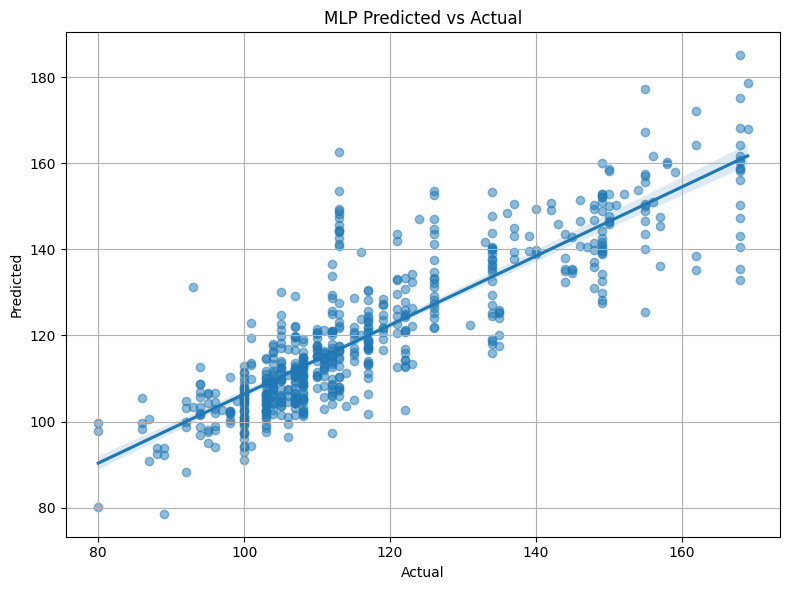

In [400]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

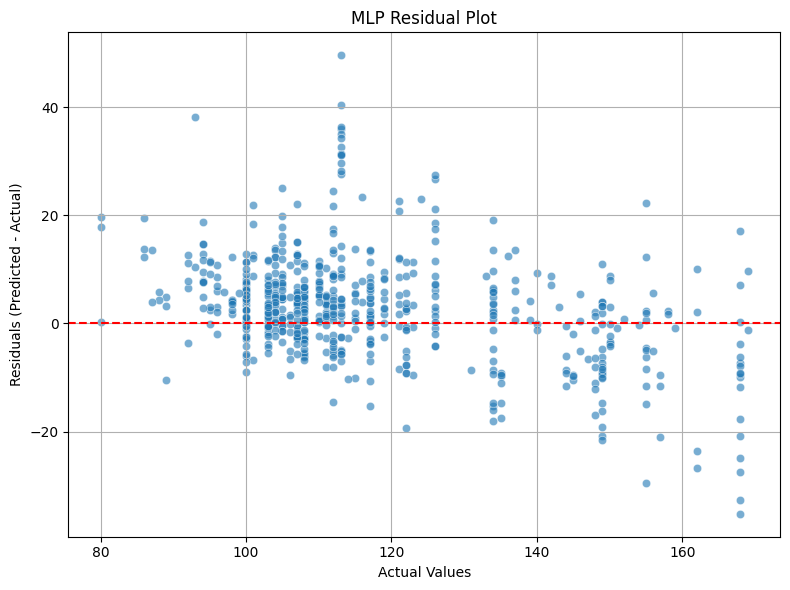

In [401]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [402]:
snps_loc= fs_data.drop(['MD', 'LL', 'LW', 'PLH', 'VBN'], axis=1)
snps_loc.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,Chr20_40195415,Chr20_43468889,Chr20_50084112,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,0,0,0,1,0,0,0,0,0,1
s100,2,1,0,2,0,1,2,0,2,0,...,0,0,0,0,0,1,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,0,1,0,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,0,0,1,0,0,0,1
s1019,0,0,0,0,0,2,2,0,0,0,...,0,2,2,0,0,1,0,0,0,1


In [403]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 127 entries, Chr1_16121722 to landrace
dtypes: int64(127)
memory usage: 2.4+ MB


In [404]:
snps_loc_dupe= fs_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
snps_loc_dupe.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,Chr20_40195415,Chr20_43468889,Chr20_50084112,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,0,0,0,1,0,0,0,0,0,1
s100,2,1,0,2,0,1,2,0,2,0,...,0,0,0,0,0,1,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,0,1,0,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,0,0,1,0,0,0,1
s1019,0,0,0,0,0,2,2,0,0,0,...,0,2,2,0,0,1,0,0,0,1


In [405]:
y_all = fs_data["MD"].values

In [406]:
X_tensor = torch.tensor(snps_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [407]:
print(X_tensor.shape)

torch.Size([2450, 127])


In [408]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [409]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 16:24:07,175] A new study created in memory with name: no-name-472529a5-f1d6-4bcb-b72f-a5fd2c7a5471
[I 2025-05-26 16:24:10,094] Trial 0 finished with value: 87.1410140991211 and parameters: {'hidden_size1': 300, 'dropout1': 0.09858437558076515, 'lr': 0.0012928475407259618, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 4.693944955287493e-05, 'n_layers': 1}. Best is trial 0 with value: 87.1410140991211.


Early stopping at epoch 99


[I 2025-05-26 16:24:12,702] Trial 1 finished with value: 4457.111328125 and parameters: {'hidden_size1': 100, 'dropout1': 0.08062534869693556, 'lr': 0.0018036362813045193, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0018302631880805342, 'n_layers': 1}. Best is trial 0 with value: 87.1410140991211.
[I 2025-05-26 16:24:19,452] Trial 2 finished with value: 332.5444641113281 and parameters: {'hidden_size1': 300, 'dropout1': 0.07716146149995787, 'lr': 0.0015362233936359474, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 1.690138097499777e-05, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout2': 0.03871112296991317}. Best is trial 0 with value: 87.1410140991211.
[I 2025-05-26 16:24:22,318] Trial 3 finished with value: 159.3657684326172 and parameters: {'hidden_size1': 200, 'dropout1': 0.09582326479085046, 'lr': 0.00037390211161084547, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 3.848793606749127e-05, 'n_layers': 1}. Best is trial 0 with value:

Early stopping at epoch 64


[I 2025-05-26 16:24:59,348] Trial 9 finished with value: 102.1601791381836 and parameters: {'hidden_size1': 100, 'dropout1': 0.041581564173568064, 'lr': 0.00046100520500453983, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.00020348005340169252, 'n_layers': 1}. Best is trial 0 with value: 87.1410140991211.
[I 2025-05-26 16:25:00,476] Trial 10 finished with value: 134.89337158203125 and parameters: {'hidden_size1': 300, 'dropout1': 0.011748853294028735, 'lr': 0.00940966919163236, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0005595796827124562, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 87.1410140991211.


...

Early stopping at epoch 48


[I 2025-05-26 16:27:33,864] Trial 48 finished with value: 94.59601593017578 and parameters: {'hidden_size1': 300, 'dropout1': 0.06131603990737973, 'lr': 0.004207304461676499, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0002475172248222557, 'n_layers': 1}. Best is trial 24 with value: 79.42463684082031.


Early stopping at epoch 71


[I 2025-05-26 16:27:36,413] Trial 49 finished with value: 131.22213745117188 and parameters: {'hidden_size1': 200, 'dropout1': 0.04655690762674104, 'lr': 0.0004604280041330984, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 9.072393977753095e-05, 'n_layers': 1}. Best is trial 24 with value: 79.42463684082031.


Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.07879100023248074, 'lr': 0.00060866063654594, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.00010969045094643379, 'n_layers': 1}


In [410]:
best_params = complete_params(study.best_params)

In [411]:
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='lasso_onlyloc_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 77 for fold 1
Fold 1 validation loss: 86.3355
Training fold 2
Early stopping at epoch 95 for fold 2
Fold 2 validation loss: 98.8120
Training fold 3
Early stopping at epoch 84 for fold 3
Fold 3 validation loss: 88.6276
Training fold 4
Early stopping at epoch 65 for fold 4
Fold 4 validation loss: 74.5822
Training fold 5
Early stopping at epoch 85 for fold 5
Fold 5 validation loss: 90.3477
Training fold 6
Early stopping at epoch 98 for fold 6
Fold 6 validation loss: 103.0536
Training fold 7
Early stopping at epoch 83 for fold 7
Fold 7 validation loss: 88.6351
Training fold 8
Early stopping at epoch 78 for fold 8
Fold 8 validation loss: 89.5132
Training fold 9
Early stopping at epoch 81 for fold 9
Fold 9 validation loss: 91.4267
Training fold 10
Early stopping at epoch 83 for fold 10
Fold 10 validation loss: 87.3272

Average validation loss across all folds: 89.8661
Checkpoint saved as 'lasso_onlyloc_mlp_md.pth'.


In [412]:
best_mlp_model

Sequential(
  (0): Linear(in_features=127, out_features=300, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.07879100023248074, inplace=False)
  (3): Linear(in_features=300, out_features=1, bias=True)
)

In [413]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [414]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [415]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [416]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 127 entries, Chr1_16121722 to landrace
dtypes: int64(127)
memory usage: 613.0+ KB


In [417]:
X_holdout.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,Chr20_40195415,Chr20_43468889,Chr20_50084112,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,1,0,0,0,0,0,1
s1019,0,0,0,0,0,2,2,0,0,0,...,0,2,2,0,1,0,0,0,0,1
s101,2,2,0,0,2,2,0,0,2,0,...,0,0,0,1,0,0,0,0,0,1
s101,2,2,0,0,2,2,0,0,2,0,...,0,0,0,0,0,0,0,1,0,1


In [418]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [419]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 109.1910
RMSE: 10.4495
MAE: 7.6712
R2: 0.7078
Holdout_Loss: 109.1911


In [420]:
pickle.dump(best_mlp_model, open("lasso_onlyloc_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 116.245995
1 148.0 141.29709
2 117.0 115.72901
3 121.0 125.34392
4 119.0 125.99978
5 94.0 104.72973


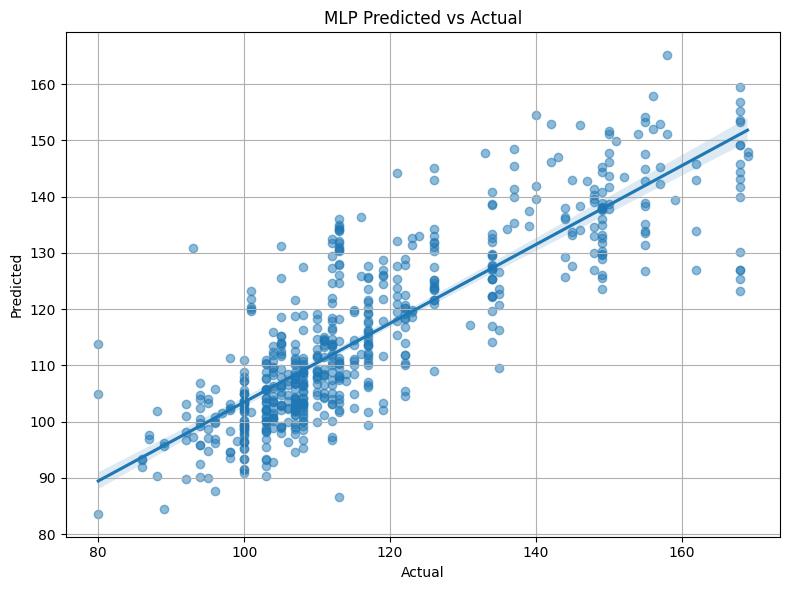

In [421]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

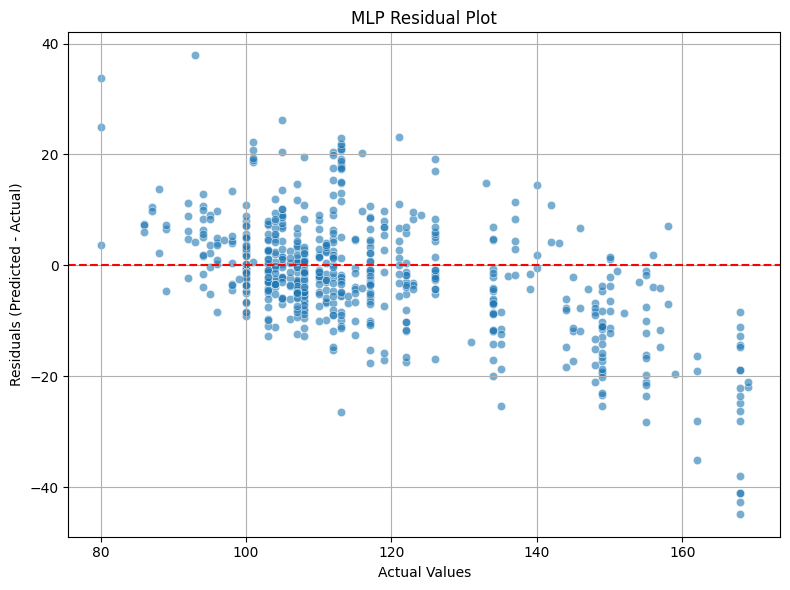

In [422]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [423]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 132 entries, Chr1_16121722 to MD
dtypes: float64(5), int64(127)
memory usage: 2.5+ MB


In [426]:
only_snps = fs_data.iloc[:, 0:120]
only_snps.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,Chr18_58493757,Chr18_59024775,Chr19_37961441,Chr19_42550797,Chr19_45117707,Chr20_2472341,Chr20_16916284,Chr20_40195415,Chr20_43468889,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,2,2,0,0,0,0,1,0,0,0
s100,2,1,0,2,0,1,2,0,2,0,...,2,2,0,0,0,0,1,0,0,0
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,2,1,2,0,0,2,0
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,2,1,2,0,0,2,0
s1019,0,0,0,0,0,2,2,0,0,0,...,0,2,0,0,0,0,0,0,2,2


In [427]:
only_snps_dupe = fs_data.iloc[:, 0:120]
only_snps_dupe.head()

,Chr1_16121722,Chr1_50820261,Chr1_53630801,Chr1_56403929,Chr1_56955989,Chr2_5508248,Chr2_15038072,Chr2_19085404,Chr2_43363394,Chr2_47732839,...,Chr18_58493757,Chr18_59024775,Chr19_37961441,Chr19_42550797,Chr19_45117707,Chr20_2472341,Chr20_16916284,Chr20_40195415,Chr20_43468889,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,1,0,2,0,1,2,0,2,0,...,2,2,0,0,0,0,1,0,0,0
s100,2,1,0,2,0,1,2,0,2,0,...,2,2,0,0,0,0,1,0,0,0
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,2,1,2,0,0,2,0
s1014,0,2,0,2,0,2,0,0,2,0,...,0,2,0,2,1,2,0,0,2,0
s1019,0,0,0,0,0,2,2,0,0,0,...,0,2,0,0,0,0,0,0,2,2


In [428]:
y_all = fs_data["MD"]
y_all.head()

Line
s100     155.0
s100     115.0
s1014    108.0
s1014    104.0
s1019    113.0
Name: MD, dtype: float64

In [429]:
# Convert to tensor and move to GPU if available
X_tensor = torch.tensor(only_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [430]:
print(X_tensor.shape)

torch.Size([2450, 120])


In [431]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [432]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 16:31:57,490] A new study created in memory with name: no-name-65d82b2b-fd2f-44f6-a108-6a1e8c76d534
[I 2025-05-26 16:31:58,948] Trial 0 finished with value: 353.27557373046875 and parameters: {'hidden_size1': 200, 'dropout1': 0.04296298102307164, 'lr': 0.0002457155989782921, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.00277802708602335, 'n_layers': 1}. Best is trial 0 with value: 353.27557373046875.


Early stopping at epoch 57


[I 2025-05-26 16:32:03,223] Trial 1 finished with value: 398.3763427734375 and parameters: {'hidden_size1': 200, 'dropout1': 0.014643643681710096, 'lr': 0.0011825566991448882, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 8.240948077014421e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 353.27557373046875.
[I 2025-05-26 16:32:06,153] Trial 2 finished with value: 350.725830078125 and parameters: {'hidden_size1': 100, 'dropout1': 0.09553537430466347, 'lr': 0.00777084352678185, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.00019386635063539992, 'n_layers': 1}. Best is trial 2 with value: 350.725830078125.


Early stopping at epoch 79


[I 2025-05-26 16:32:07,420] Trial 3 finished with value: 354.23468017578125 and parameters: {'hidden_size1': 200, 'dropout1': 0.018218218434465288, 'lr': 0.0003622790268559517, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0012181029691386896, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout2': 0.09912936294818776}. Best is trial 2 with value: 350.725830078125.


...

Early stopping at epoch 25


[I 2025-05-26 16:34:19,909] Trial 47 finished with value: 343.6003723144531 and parameters: {'hidden_size1': 300, 'dropout1': 0.019974467156698504, 'lr': 0.00792022749980378, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.00013707374473054628, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 33 with value: 337.009521484375.


Early stopping at epoch 39


[I 2025-05-26 16:34:24,215] Trial 48 finished with value: 11204.7880859375 and parameters: {'hidden_size1': 100, 'dropout1': 0.08015790018475219, 'lr': 0.00041093954651451613, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.00044705127245967745, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 33 with value: 337.009521484375.
[I 2025-05-26 16:34:28,481] Trial 49 finished with value: 13393.6494140625 and parameters: {'hidden_size1': 300, 'dropout1': 0.09308206399062087, 'lr': 0.00011248778555648212, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.00022168802161216244, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 33 with value: 337.009521484375.


Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.07469837117656136, 'lr': 0.0033536442660900795, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.00040856661466695456, 'n_layers': 2, 'hidden_size2': 50}


In [433]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='lasso_onlysnps_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 23 for fold 1
Fold 1 validation loss: 343.6483
Training fold 2
Early stopping at epoch 76 for fold 2
Fold 2 validation loss: 365.9536
Training fold 3
Early stopping at epoch 80 for fold 3
Fold 3 validation loss: 390.2115
Training fold 4
Early stopping at epoch 75 for fold 4
Fold 4 validation loss: 325.7738
Training fold 5
Early stopping at epoch 76 for fold 5
Fold 5 validation loss: 323.6672
Training fold 6
Early stopping at epoch 24 for fold 6
Fold 6 validation loss: 413.1057
Training fold 7
Early stopping at epoch 89 for fold 7
Fold 7 validation loss: 368.5499
Training fold 8
Early stopping at epoch 74 for fold 8
Fold 8 validation loss: 313.6155
Training fold 9
Early stopping at epoch 76 for fold 9
Fold 9 validation loss: 306.8743
Training fold 10
Early stopping at epoch 85 for fold 10
Fold 10 validation loss: 432.5704

Average validation loss across all folds: 358.3970
Checkpoint saved as 'lasso_onlysnps_mlp_md.pth'.


In [312]:
best_mlp_model

Sequential(
  (0): Linear(in_features=191, out_features=300, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.036031425832586006, inplace=False)
  (3): Linear(in_features=300, out_features=100, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.0422971103224956, inplace=False)
  (6): Linear(in_features=100, out_features=50, bias=True)
  (7): ReLU()
  (8): Linear(in_features=50, out_features=1, bias=True)
)

In [313]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [314]:
holdout_data = holdout_data.set_index('Line')

In [434]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [435]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [436]:
# Ensure both trainjg and holdout datasets have the same columns
only_snps_dupe, X_holdout = only_snps_dupe.align(X_holdout, join='inner', axis=1)

In [437]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 120 entries, Chr1_16121722 to Chr20_50084112
dtypes: int64(120)
memory usage: 579.5+ KB


In [438]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [439]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 432.5306
RMSE: 20.7974
MAE: 16.5987
R2: -0.1575
Holdout_Loss: 432.5306


In [440]:
pickle.dump(best_mlp_model, open("lasso_onlysnps_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

# ElasticNet

In [322]:
fs_data = pd.read_pickle("pickle_files/fs_md_enet_training_data.pkl")

In [323]:
fs_data.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,0,0,1,2,1,0,0,2,2,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,2,2,0,0,2,2,0,1,2,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,2,2,0,0,2,2,0,1,2,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,0,0,0,0,0,0,0,1,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


### All covariates

In [325]:
X_all = fs_data.drop("MD", axis=1).values
y_all = fs_data["MD"].values

In [326]:
X_dupe = fs_data.drop("MD", axis=1)
X_dupe.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,0,0,1,2,1,0,0,2,2,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1
s1019,0,0,0,0,0,0,0,1,0,0,...,7.34667,61.0,4.60000,0,0,1,0,0,0,1


In [327]:
X_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [328]:
print(X_tensor.shape)

torch.Size([2450, 347])


In [329]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [330]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 15:57:21,919] A new study created in memory with name: no-name-5f24c7e8-660e-4e00-bdc2-547f9f1796bd
[I 2025-05-26 15:57:28,069] Trial 0 finished with value: 147.46156311035156 and parameters: {'hidden_size1': 100, 'dropout1': 0.08671642784694651, 'lr': 0.00015718651785464436, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.006893883798548849, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 147.46156311035156.


Early stopping at epoch 74


[I 2025-05-26 15:57:29,585] Trial 1 finished with value: 123.72772979736328 and parameters: {'hidden_size1': 300, 'dropout1': 0.03792665098779476, 'lr': 0.005637601817714636, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0004033755495068092, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 1 with value: 123.72772979736328.


Early stopping at epoch 52


[I 2025-05-26 15:57:37,112] Trial 2 finished with value: 169.90133666992188 and parameters: {'hidden_size1': 200, 'dropout1': 0.030842359511147013, 'lr': 0.004878973623936438, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 7.412604756976203e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 1 with value: 123.72772979736328.
[I 2025-05-26 15:57:38,759] Trial 3 finished with value: 98.23265075683594 and parameters: {'hidden_size1': 300, 'dropout1': 0.0719761111621983, 'lr': 0.003965937242609957, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 6.706052151736037e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.0538467064146595}. Best is trial 3 with value: 98.23265075683594.


...

Early stopping at epoch 87


[I 2025-05-26 16:00:03,162] Trial 48 finished with value: 84.43610382080078 and parameters: {'hidden_size1': 300, 'dropout1': 0.04565983435587201, 'lr': 0.000746288362792053, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 3.2965308259827326e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 48 with value: 84.43610382080078.


Early stopping at epoch 96


[I 2025-05-26 16:00:05,809] Trial 49 finished with value: 1578.5054931640625 and parameters: {'hidden_size1': 300, 'dropout1': 0.07021426090885584, 'lr': 0.0007220161818643879, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 3.051835867424572e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 48 with value: 84.43610382080078.


Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.04565983435587201, 'lr': 0.000746288362792053, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 3.2965308259827326e-05, 'n_layers': 2, 'hidden_size2': 100}


In [331]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='enet_allfeats_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 79 for fold 1
Fold 1 validation loss: 84.3013
Training fold 2
Early stopping at epoch 80 for fold 2
Fold 2 validation loss: 94.1664
Training fold 3
Early stopping at epoch 89 for fold 3
Fold 3 validation loss: 106.8996
Training fold 4
Early stopping at epoch 70 for fold 4
Fold 4 validation loss: 87.0130
Training fold 5
Early stopping at epoch 84 for fold 5
Fold 5 validation loss: 105.9697
Training fold 6
Early stopping at epoch 73 for fold 6
Fold 6 validation loss: 107.0470
Training fold 7
Fold 7 validation loss: 86.7412
Training fold 8
Early stopping at epoch 97 for fold 8
Fold 8 validation loss: 105.5608
Training fold 9
Fold 9 validation loss: 91.7257
Training fold 10
Fold 10 validation loss: 98.7026

Average validation loss across all folds: 96.8127
Checkpoint saved as 'enet_allfeats_mlp_md.pth'.


In [332]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [333]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [334]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [335]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [337]:
# Ensure both trainjg and holdout datasets have the same columns
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [338]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 347 entries, Chr1_2475213 to landrace
dtypes: float64(4), int64(343)
memory usage: 1.6+ MB


In [339]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [340]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 135.1129
RMSE: 11.6238
MAE: 8.1724
R2: 0.6384
Holdout_Loss: 135.1129


In [341]:
pickle.dump(best_mlp_model, open("enet_allfeats_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 120.53958
1 148.0 151.32156
2 117.0 114.66601
3 121.0 118.24234
4 119.0 118.396996
5 94.0 99.93115


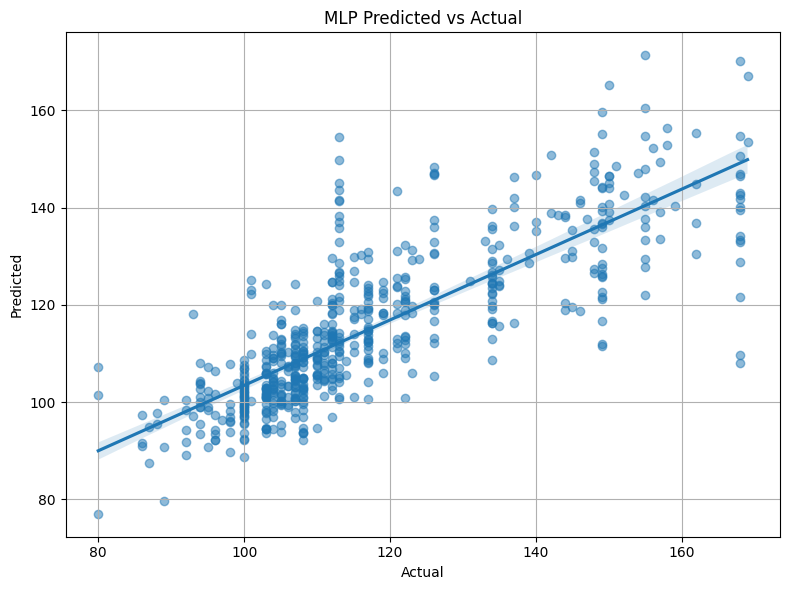

In [342]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

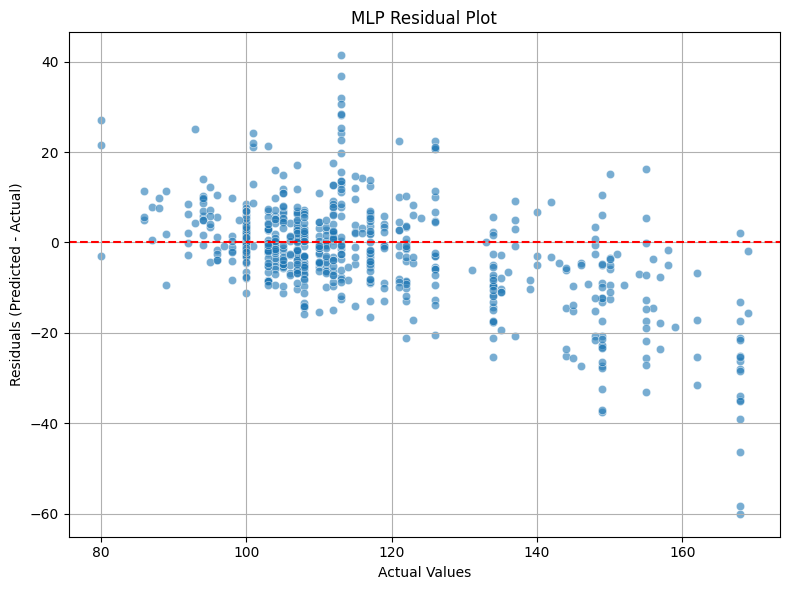

In [343]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [344]:
snps_loc= fs_data.drop(['MD', 'LL', 'LW', 'PLH', 'VBN'], axis=1)
snps_loc.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,Chr20_50003028,Chr20_50084112,Chr20_51274009,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,2,0,0,1,0,0,0,0,0,1
s100,0,0,1,2,1,0,0,2,2,0,...,2,0,0,0,0,1,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,2,0,2,0,1,0,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,2,0,2,0,0,1,0,0,0,1
s1019,0,0,0,0,0,0,0,1,0,0,...,2,2,0,0,0,1,0,0,0,1


In [345]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 343 entries, Chr1_2475213 to landrace
dtypes: int64(343)
memory usage: 6.4+ MB


In [346]:
snps_loc_dupe= fs_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
snps_loc_dupe.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,Chr20_50003028,Chr20_50084112,Chr20_51274009,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,2,0,0,1,0,0,0,0,0,1
s100,0,0,1,2,1,0,0,2,2,0,...,2,0,0,0,0,1,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,2,0,2,0,1,0,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,2,0,2,0,0,1,0,0,0,1
s1019,0,0,0,0,0,0,0,1,0,0,...,2,2,0,0,0,1,0,0,0,1


In [347]:
y_all = fs_data["MD"].values

In [348]:
X_tensor = torch.tensor(snps_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [349]:
print(X_tensor.shape)

torch.Size([2450, 343])


In [350]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [351]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 16:03:06,704] A new study created in memory with name: no-name-518f57d2-e5b0-457e-94d6-925f00838a52
[I 2025-05-26 16:03:09,074] Trial 0 finished with value: 82.21165466308594 and parameters: {'hidden_size1': 200, 'dropout1': 0.013717512122777036, 'lr': 0.0006081681205178084, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.00017988886248116462, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout2': 0.06890061260099277}. Best is trial 0 with value: 82.21165466308594.


Early stopping at epoch 74


[I 2025-05-26 16:03:13,518] Trial 1 finished with value: 92.78450012207031 and parameters: {'hidden_size1': 100, 'dropout1': 0.013650206223512918, 'lr': 0.00027806339633503553, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0013720770940788072, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 82.21165466308594.
[I 2025-05-26 16:03:17,782] Trial 2 finished with value: 307.8468933105469 and parameters: {'hidden_size1': 100, 'dropout1': 0.07412168605387585, 'lr': 0.0016101500141297868, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 2.9770465748210806e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 82.21165466308594.
[I 2025-05-26 16:03:22,051] Trial 3 finished with value: 232.58450317382812 and parameters: {'hidden_size1': 300, 'dropout1': 0.05891399670964168, 'lr': 0.004013583517364712, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.00015549833087963622, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 82.21

Early stopping at epoch 77


[I 2025-05-26 16:03:25,116] Trial 5 finished with value: 188.95541381835938 and parameters: {'hidden_size1': 200, 'dropout1': 0.09043228745847576, 'lr': 0.004912400544175551, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0001418330498921171, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout2': 0.08761898323434304}. Best is trial 0 with value: 82.21165466308594.


...

Early stopping at epoch 100


[I 2025-05-26 16:07:55,660] Trial 47 finished with value: 95.67768859863281 and parameters: {'hidden_size1': 300, 'dropout1': 0.09938673078813991, 'lr': 0.0003632518647092689, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.00046514329599161956, 'n_layers': 1}. Best is trial 34 with value: 66.17378997802734.
[I 2025-05-26 16:08:04,787] Trial 48 finished with value: 82.49931335449219 and parameters: {'hidden_size1': 100, 'dropout1': 0.059870953787777195, 'lr': 0.00020089481249148324, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0005119997675526853, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout2': 0.04484802400403555}. Best is trial 34 with value: 66.17378997802734.


Early stopping at epoch 96


[I 2025-05-26 16:08:07,604] Trial 49 finished with value: 76.27532196044922 and parameters: {'hidden_size1': 200, 'dropout1': 0.05342164374734026, 'lr': 0.0004998821527766214, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.00012723039597770238, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 34 with value: 66.17378997802734.


Best hyperparameters: {'hidden_size1': 200, 'dropout1': 0.08432586111622883, 'lr': 0.00017780016540560123, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0001274067258494182, 'n_layers': 2, 'hidden_size2': 150}


In [353]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='enet_onlyloc_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 97 for fold 1
Fold 1 validation loss: 68.1016
Training fold 2
Fold 2 validation loss: 85.5355
Training fold 3
Early stopping at epoch 76 for fold 3
Fold 3 validation loss: 97.0215
Training fold 4
Fold 4 validation loss: 82.4937
Training fold 5
Fold 5 validation loss: 78.9322
Training fold 6
Fold 6 validation loss: 85.2553
Training fold 7
Early stopping at epoch 88 for fold 7
Fold 7 validation loss: 85.3507
Training fold 8
Fold 8 validation loss: 93.8116
Training fold 9
Early stopping at epoch 63 for fold 9
Fold 9 validation loss: 101.1663
Training fold 10
Early stopping at epoch 94 for fold 10
Fold 10 validation loss: 94.2076

Average validation loss across all folds: 87.1876
Checkpoint saved as 'enet_onlyloc_mlp_md.pth'.


In [354]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [355]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [356]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [357]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 343 entries, Chr1_2475213 to landrace
dtypes: int64(343)
memory usage: 1.6+ MB


In [358]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [359]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 116.5278
RMSE: 10.7948
MAE: 7.5096
R2: 0.6881
Holdout_Loss: 116.5278


In [360]:
pickle.dump(best_mlp_model, open("enet_onlyloc_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 118.60944
1 148.0 144.37344
2 117.0 118.47116
3 121.0 120.7145
4 119.0 123.18575
5 94.0 98.05328


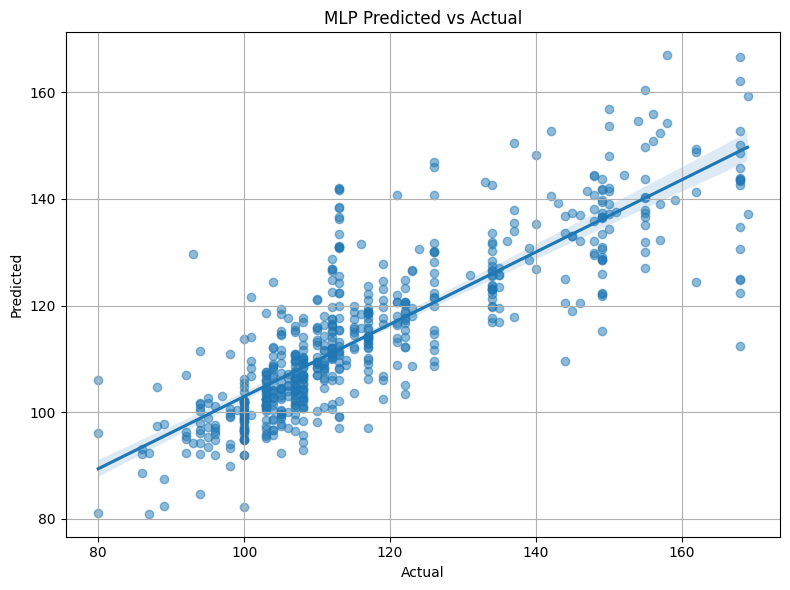

In [361]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

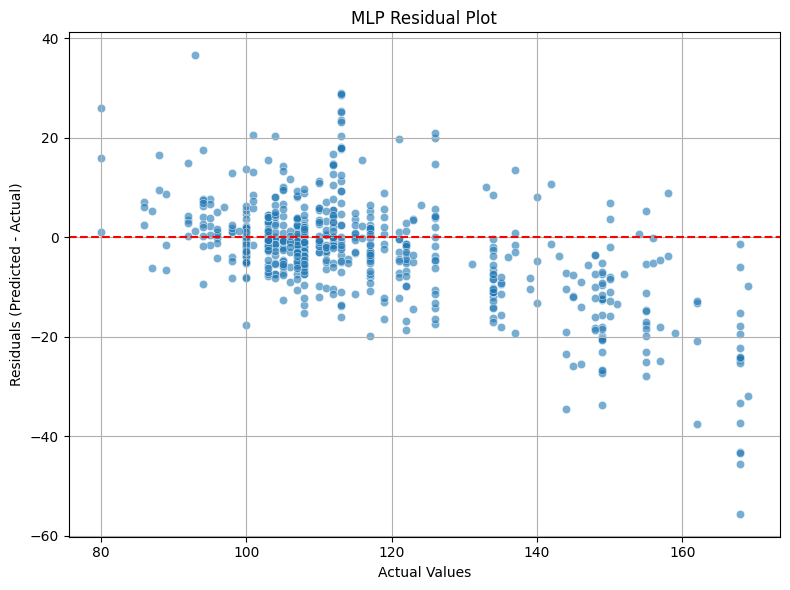

In [362]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [363]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 348 entries, Chr1_2475213 to MD
dtypes: float64(5), int64(343)
memory usage: 6.5+ MB


In [366]:
X_snps = fs_data.iloc[:, 0:336]
X_snps.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,Chr20_39258975,Chr20_39890366,Chr20_40195415,Chr20_40942681,Chr20_43468889,Chr20_43870603,Chr20_48582557,Chr20_50003028,Chr20_50084112,Chr20_51274009
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,0,0,0,0,0,0,0,2,0,0
s100,0,0,1,2,1,0,0,2,2,0,...,0,0,0,0,0,0,0,2,0,0
s1014,2,2,0,0,2,2,0,1,2,0,...,0,0,0,0,2,2,0,2,0,2
s1014,2,2,0,0,2,2,0,1,2,0,...,0,0,0,0,2,2,0,2,0,2
s1019,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,2,2,0,2,2,0


In [368]:
X_snps_dupe = fs_data.iloc[:, 0:336]
X_snps_dupe.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,Chr20_39258975,Chr20_39890366,Chr20_40195415,Chr20_40942681,Chr20_43468889,Chr20_43870603,Chr20_48582557,Chr20_50003028,Chr20_50084112,Chr20_51274009
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,0,0,0,0,0,0,0,2,0,0
s100,0,0,1,2,1,0,0,2,2,0,...,0,0,0,0,0,0,0,2,0,0
s1014,2,2,0,0,2,2,0,1,2,0,...,0,0,0,0,2,2,0,2,0,2
s1014,2,2,0,0,2,2,0,1,2,0,...,0,0,0,0,2,2,0,2,0,2
s1019,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,2,2,0,2,2,0


In [369]:
y_all = fs_data.iloc[:, 347:]
y_all.head()

,MD
Line,
s100,155.0
s100,115.0
s1014,108.0
s1014,104.0
s1019,113.0


In [370]:
X_tensor = torch.tensor(X_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [371]:
print(X_tensor.shape)

torch.Size([2450, 336])


In [372]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [373]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-26 16:12:30,517] A new study created in memory with name: no-name-8232d0b4-f2bf-43e8-9b9d-73a3123b7eed
[I 2025-05-26 16:12:32,081] Trial 0 finished with value: 346.1969909667969 and parameters: {'hidden_size1': 300, 'dropout1': 0.09059405687024497, 'lr': 0.0035625061737125864, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.00021404929111413633, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout2': 0.01937913440495554}. Best is trial 0 with value: 346.1969909667969.


Early stopping at epoch 29


[I 2025-05-26 16:12:32,828] Trial 1 finished with value: 307.3112487792969 and parameters: {'hidden_size1': 300, 'dropout1': 0.05648342891484378, 'lr': 0.0038184641304575546, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0005255284699495843, 'n_layers': 1}. Best is trial 1 with value: 307.3112487792969.


Early stopping at epoch 27


[I 2025-05-26 16:12:34,471] Trial 2 finished with value: 331.9582214355469 and parameters: {'hidden_size1': 300, 'dropout1': 0.03028557034820726, 'lr': 0.00423569059902871, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0004899628387709615, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 1 with value: 307.3112487792969.


...

Early stopping at epoch 82


[I 2025-05-26 16:14:02,309] Trial 47 finished with value: 12666.30859375 and parameters: {'hidden_size1': 100, 'dropout1': 0.04355772733414266, 'lr': 0.00016435002222969566, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0006949698719207357, 'n_layers': 1}. Best is trial 33 with value: 279.63177490234375.
[I 2025-05-26 16:14:03,711] Trial 48 finished with value: 283.04962158203125 and parameters: {'hidden_size1': 100, 'dropout1': 0.035843279297359136, 'lr': 0.00034747373523035343, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0016152588981813165, 'n_layers': 1}. Best is trial 33 with value: 279.63177490234375.


Early stopping at epoch 53


[I 2025-05-26 16:14:04,325] Trial 49 finished with value: 298.6817626953125 and parameters: {'hidden_size1': 100, 'dropout1': 0.024350953928145673, 'lr': 0.0010544435342021187, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0008131937242408055, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 33 with value: 279.63177490234375.


Early stopping at epoch 21
Best hyperparameters: {'hidden_size1': 100, 'dropout1': 0.02781157529513765, 'lr': 0.00010611978079127906, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.000708425737653844, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout2': 0.08939640004581431}


In [374]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='enet_onlysnps_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 49 for fold 1
Fold 1 validation loss: 280.8768
Training fold 2
Early stopping at epoch 63 for fold 2
Fold 2 validation loss: 295.6999
Training fold 3
Early stopping at epoch 56 for fold 3
Fold 3 validation loss: 338.2239
Training fold 4
Early stopping at epoch 60 for fold 4
Fold 4 validation loss: 289.9575
Training fold 5
Early stopping at epoch 60 for fold 5
Fold 5 validation loss: 270.8308
Training fold 6
Early stopping at epoch 49 for fold 6
Fold 6 validation loss: 333.9879
Training fold 7
Early stopping at epoch 60 for fold 7
Fold 7 validation loss: 313.4255
Training fold 8
Early stopping at epoch 41 for fold 8
Fold 8 validation loss: 283.3406
Training fold 9
Early stopping at epoch 68 for fold 9
Fold 9 validation loss: 260.0701
Training fold 10
Early stopping at epoch 75 for fold 10
Fold 10 validation loss: 367.2470

Average validation loss across all folds: 303.3660
Checkpoint saved as 'enet_onlysnps_mlp_md.pth'.


In [375]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [376]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [377]:
# Ensure both trainjg and holdout datasets have the same columns
X_snps_dupe, X_holdout = X_snps_dupe.align(X_holdout, join='inner', axis=1)

In [378]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [379]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 457.9166
RMSE: 21.3990
MAE: 16.5354
R2: -0.2255
Holdout_Loss: 457.9166


In [380]:
pickle.dump(best_mlp_model, open("enet_onlysnps_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

# XGBoost

In [9]:
tt_data = pd.read_pickle("fs_md_xgboost_training_data.pkl")
tt_data.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,0,0,0,0,1,0,0,0,2,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,0,1,0,0,0,0,0,2,2,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,1,0,0,0,0,0,2,2,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,0,0,0,1,0,0,0,0,1,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


## All covariates

In [10]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,MD
Line,
s100,155.0
s100,115.0
s1014,108.0
s1014,104.0
s1019,113.0


In [11]:
tt_all= tt_data.drop(['MD'], axis=1)
tt_all.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,0,0,0,1,0,0,0,2,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1
s1019,0,0,0,1,0,0,0,0,1,0,...,7.34667,61.0,4.60000,0,0,1,0,0,0,1


In [12]:
tt_all_dupe= tt_data.drop(['MD'], axis=1)
tt_all_dupe.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,0,0,0,1,0,0,0,2,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1
s1019,0,0,0,1,0,0,0,0,1,0,...,7.34667,61.0,4.60000,0,0,1,0,0,0,1


In [13]:
X_tensor = torch.tensor(tt_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(tt_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [14]:
print(X_tensor.shape)

torch.Size([2450, 1011])


In [15]:
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [16]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-29 18:23:12,339] A new study created in memory with name: no-name-d83880f9-1f4e-49f8-b8c2-3c99f193f22b
[I 2025-05-29 18:23:15,777] Trial 0 finished with value: 11433.3876953125 and parameters: {'hidden_size1': 300, 'dropout1': 0.039320897875877406, 'lr': 0.0001460969441343554, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0011452425184501288, 'n_layers': 1}. Best is trial 0 with value: 11433.3876953125.
[I 2025-05-29 18:23:17,864] Trial 1 finished with value: 141.13563537597656 and parameters: {'hidden_size1': 100, 'dropout1': 0.05920968525094979, 'lr': 0.0022446296420093378, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.00021464765149735562, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout2': 0.07468311671634291}. Best is trial 1 with value: 141.13563537597656.


Early stopping at epoch 55


[I 2025-05-29 18:23:19,973] Trial 2 finished with value: 232.988525390625 and parameters: {'hidden_size1': 100, 'dropout1': 0.020851928543399498, 'lr': 0.0013684039680433564, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.00022887966249421468, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout2': 0.09841786220664304}. Best is trial 1 with value: 141.13563537597656.


Early stopping at epoch 38


[I 2025-05-29 18:23:25,298] Trial 3 finished with value: 205.48379516601562 and parameters: {'hidden_size1': 200, 'dropout1': 0.06179382034247294, 'lr': 0.007200420023835082, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0027362241708951966, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout2': 0.05686286658663159}. Best is trial 1 with value: 141.13563537597656.
[I 2025-05-29 18:23:28,531] Trial 4 finished with value: 243.53794860839844 and parameters: {'hidden_size1': 100, 'dropout1': 0.047555987485088505, 'lr': 0.004603271370281277, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.002131203652072064, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout2': 0.023321487683587785}. Best is trial 1 with value: 141.13563537597656.
[I 2025-05-29 18:23:30,912] Trial 5 finished with value: 131.7602081298828 and parameters: {'hidden_size1': 200, 'dropout1': 0.011046442815915825, 'lr': 0.0026784009303648755, 'batch_size': 128, 'optimizer': 'Adam', 'we

...

Early stopping at epoch 68


[I 2025-05-29 18:27:08,487] Trial 48 finished with value: 159.71157836914062 and parameters: {'hidden_size1': 300, 'dropout1': 0.0752052707449633, 'lr': 0.00026644801314854055, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.004375449844849473, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 31 with value: 94.66083526611328.


Early stopping at epoch 65


[I 2025-05-29 18:27:15,837] Trial 49 finished with value: 132.2730255126953 and parameters: {'hidden_size1': 100, 'dropout1': 0.08706257008201775, 'lr': 0.00040807999332397965, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0008421254492299432, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 31 with value: 94.66083526611328.


Early stopping at epoch 80
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.09820223477520951, 'lr': 0.0003016688096255801, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 2.828463266308654e-05, 'n_layers': 2, 'hidden_size2': 50}


In [17]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='xgboost_allfeats_mlp_md_test.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 95.4988
Training fold 2
Early stopping at epoch 59 for fold 2
Fold 2 validation loss: 128.5892
Training fold 3
Fold 3 validation loss: 121.0698
Training fold 4
Fold 4 validation loss: 106.5502
Training fold 5
Fold 5 validation loss: 137.3954
Training fold 6
Early stopping at epoch 86 for fold 6
Fold 6 validation loss: 127.1341
Training fold 7
Fold 7 validation loss: 113.7911
Training fold 8
Fold 8 validation loss: 120.2467
Training fold 9
Early stopping at epoch 71 for fold 9
Fold 9 validation loss: 129.8411
Training fold 10
Fold 10 validation loss: 134.8230

Average validation loss across all folds: 121.4939
Checkpoint saved as 'xgboost_allfeats_mlp_md_test.pth'.


In [18]:
best_mlp_model

Sequential(
  (0): Linear(in_features=1011, out_features=300, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.09820223477520951, inplace=False)
  (3): Linear(in_features=300, out_features=50, bias=True)
  (4): ReLU()
  (5): Linear(in_features=50, out_features=1, bias=True)
)

In [19]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [20]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [21]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [22]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [23]:
tt_all_dupe, X_holdout = tt_all_dupe.align(X_holdout, join='inner', axis=1)

In [24]:
X_holdout.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,1,0,0,0,0,1,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,0,0,0,1,1,1,1,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,0,0,0,1,1,1,1,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [25]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [26]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 140.6216
RMSE: 11.8584
MAE: 8.5989
R2: 0.6237
Holdout_Loss: 140.6216


In [27]:
pickle.dump(best_mlp_model, open("xgboost_allfeats_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 121.90238
1 148.0 162.7461
2 117.0 116.88693
3 121.0 110.74391
4 119.0 111.76458
5 94.0 103.05442


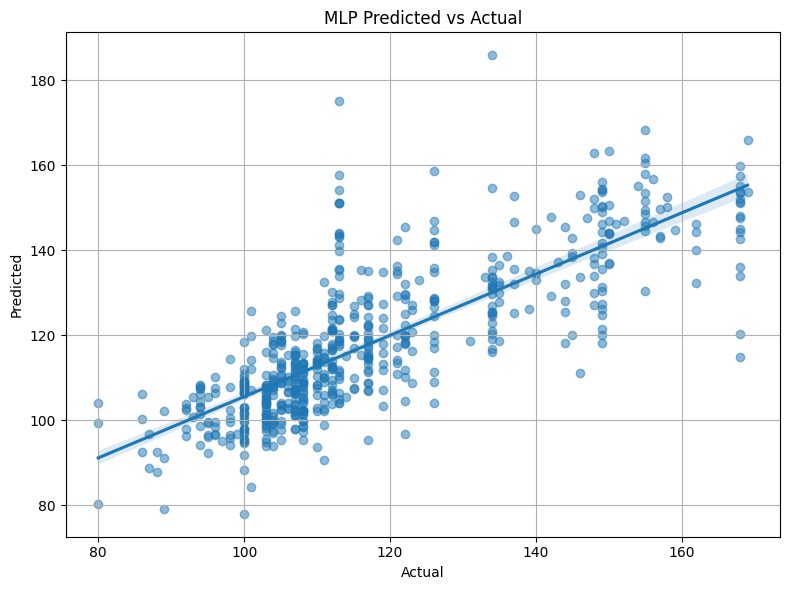

In [28]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

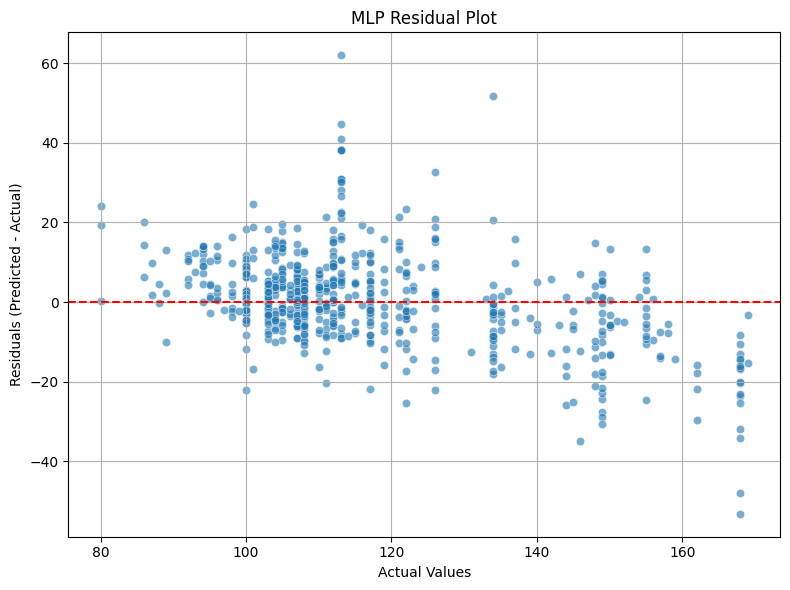

In [29]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

## Only location

In [30]:
tt_loc= tt_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
tt_loc.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr3_40105409,Chr4_35874454,Chr12_16805346,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,1,0,0,1,0,0,0,0,0,1
s100,1,0,0,0,0,1,0,0,0,2,...,1,0,0,0,0,1,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,0,0,0,0,0,1,0,0,0,1
s1019,0,0,0,1,0,0,0,0,1,0,...,0,0,2,0,0,1,0,0,0,1


In [31]:
tt_loc_dupe= tt_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
tt_loc_dupe.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr3_40105409,Chr4_35874454,Chr12_16805346,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,1,0,0,1,0,0,0,0,0,1
s100,1,0,0,0,0,1,0,0,0,2,...,1,0,0,0,0,1,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,0,0,0,0,0,1,0,0,0,1
s1019,0,0,0,1,0,0,0,0,1,0,...,0,0,2,0,0,1,0,0,0,1


In [32]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,MD
Line,
s100,155.0
s100,115.0
s1014,108.0
s1014,104.0
s1019,113.0


In [33]:
X_tensor = torch.tensor(tt_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(tt_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [34]:
print(X_tensor.shape)

torch.Size([2450, 1007])


In [35]:
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [36]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-29 18:36:04,788] A new study created in memory with name: no-name-669f4441-6243-4862-8802-bcd5230cc23c
[I 2025-05-29 18:36:07,199] Trial 0 finished with value: 135.728271484375 and parameters: {'hidden_size1': 200, 'dropout1': 0.012750804210149114, 'lr': 0.0012484822374621333, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 2.3519442023235085e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 135.728271484375.


Early stopping at epoch 75


[I 2025-05-29 18:36:10,187] Trial 1 finished with value: 12840.1123046875 and parameters: {'hidden_size1': 300, 'dropout1': 0.03265365806814872, 'lr': 0.00037229101118163544, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0007707133957594814, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 0 with value: 135.728271484375.
[I 2025-05-29 18:36:12,923] Trial 2 finished with value: 535.0516357421875 and parameters: {'hidden_size1': 300, 'dropout1': 0.08094641133265067, 'lr': 0.006700286447715193, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 6.952915480592893e-05, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout2': 0.013732540109414972}. Best is trial 0 with value: 135.728271484375.


Early stopping at epoch 27


[I 2025-05-29 18:36:15,796] Trial 3 finished with value: 8278.0 and parameters: {'hidden_size1': 100, 'dropout1': 0.07438315502663395, 'lr': 0.0008992501952851413, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 6.864754151465855e-05, 'n_layers': 2, 'hidden_size2': 100}. Best is trial 0 with value: 135.728271484375.
[I 2025-05-29 18:36:17,819] Trial 4 finished with value: 124.26825714111328 and parameters: {'hidden_size1': 300, 'dropout1': 0.025047931828653468, 'lr': 0.002157525378889795, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0005081763582647055, 'n_layers': 1}. Best is trial 4 with value: 124.26825714111328.


...

Early stopping at epoch 99


[I 2025-05-29 18:40:12,284] Trial 45 finished with value: 105.40835571289062 and parameters: {'hidden_size1': 100, 'dropout1': 0.07258276342689617, 'lr': 0.00015446567267292255, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 4.406793940714154e-05, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout2': 0.05531744021580686}. Best is trial 42 with value: 86.11326599121094.


Early stopping at epoch 86


[I 2025-05-29 18:40:18,227] Trial 46 finished with value: 111.91751861572266 and parameters: {'hidden_size1': 100, 'dropout1': 0.06113753373184845, 'lr': 0.00012702413426877293, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 2.8745883924049593e-05, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout2': 0.08999231583806683}. Best is trial 42 with value: 86.11326599121094.
[I 2025-05-29 18:40:26,505] Trial 47 finished with value: 6238.76416015625 and parameters: {'hidden_size1': 100, 'dropout1': 0.047084226513712614, 'lr': 0.00027236711153016046, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 1.0039172167196432e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 42 with value: 86.11326599121094.
[I 2025-05-29 18:40:37,169] Trial 48 finished with value: 108.66132354736328 and parameters: {'hidden_size1': 100, 'dropout1': 0.07891329436100859, 'lr': 0.00015058437492694945, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.343722703203307e-05, 'n_layers

Best hyperparameters: {'hidden_size1': 100, 'dropout1': 0.05748788168874336, 'lr': 0.00012611836414209938, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.3014063247307612e-05, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout2': 0.09981521698271426}


In [37]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='xgboost_onlyloc_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 76 for fold 1
Fold 1 validation loss: 104.6307
Training fold 2
Fold 2 validation loss: 115.1141
Training fold 3
Fold 3 validation loss: 107.0654
Training fold 4
Fold 4 validation loss: 94.4018
Training fold 5
Fold 5 validation loss: 121.6804
Training fold 6
Fold 6 validation loss: 126.2312
Training fold 7
Fold 7 validation loss: 113.2246
Training fold 8
Fold 8 validation loss: 120.3202
Training fold 9
Early stopping at epoch 92 for fold 9
Fold 9 validation loss: 126.4086
Training fold 10
Fold 10 validation loss: 136.9688

Average validation loss across all folds: 116.6046
Checkpoint saved as 'xgboost_onlyloc_mlp_md.pth'.


In [38]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [39]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [40]:
tt_loc, X_holdout = tt_loc_dupe.align(X_holdout, join='inner', axis=1)

In [41]:
X_holdout.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr3_40105409,Chr4_35874454,Chr12_16805346,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,1,0,0,0,1,0,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,0,0,0,1,0,0,0,0,0,1
s1019,0,0,0,1,0,0,0,0,1,0,...,0,0,2,0,1,0,0,0,0,1
s101,0,0,0,0,0,1,1,1,1,0,...,1,0,0,1,0,0,0,0,0,1
s101,0,0,0,0,0,1,1,1,1,0,...,1,0,0,0,0,0,0,1,0,1


In [42]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [43]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 121.1831
RMSE: 11.0083
MAE: 7.8805
R2: 0.6757
Holdout_Loss: 121.1831


In [44]:
pickle.dump(best_mlp_model, open("xgboost_onlyloc_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 117.30932
1 148.0 148.01756
2 117.0 119.308914
3 121.0 128.59865
4 119.0 128.80809
5 94.0 100.209305


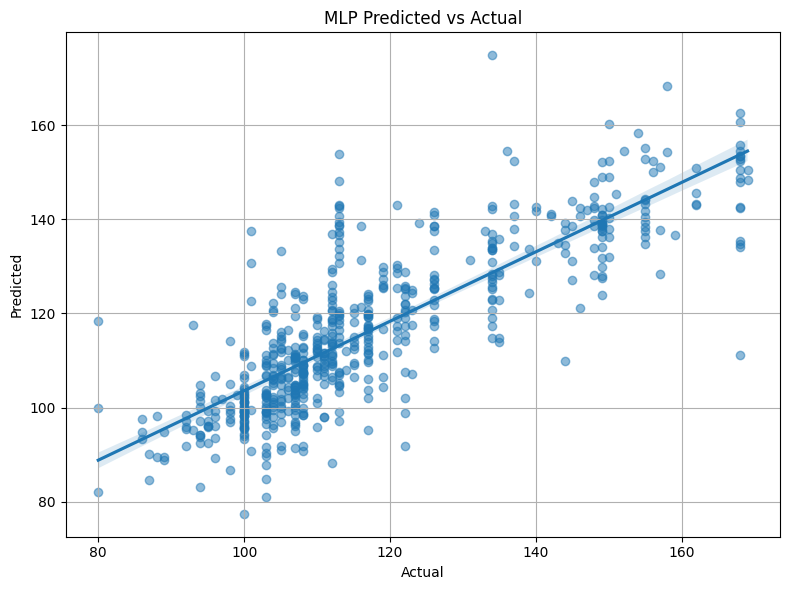

In [45]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

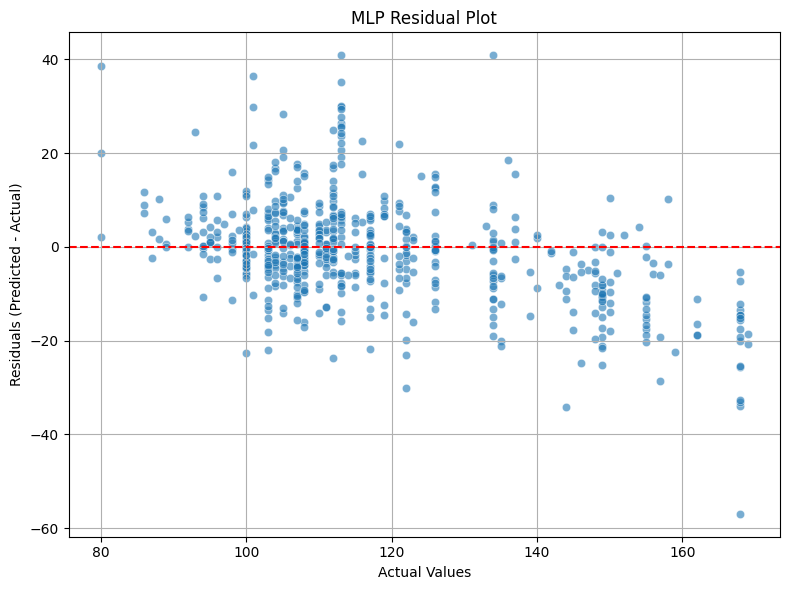

In [46]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

## Only SNPs

In [47]:
tt_snps = tt_data.iloc[:, 0:1000]
tt_snps.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr20_32404414,Chr14_11784839,Chr1_15174358,Chr16_37617327,Chr14_32962588,Chr18_45197353,Chr17_20583513,Chr3_40105409,Chr4_35874454,Chr12_16805346
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,0,2,0,1,0,0,1,1,0,0
s100,1,0,0,0,0,1,0,0,0,2,...,0,2,0,1,0,0,1,1,0,0
s1014,0,1,0,0,0,0,0,2,2,0,...,0,2,2,0,0,1,0,0,0,0
s1014,0,1,0,0,0,0,0,2,2,0,...,0,2,2,0,0,1,0,0,0,0
s1019,0,0,0,1,0,0,0,0,1,0,...,0,2,0,1,0,0,0,0,0,2


In [48]:
tt_snps_dupe = tt_data.iloc[:, 0:1000]
tt_snps_dupe.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr20_32404414,Chr14_11784839,Chr1_15174358,Chr16_37617327,Chr14_32962588,Chr18_45197353,Chr17_20583513,Chr3_40105409,Chr4_35874454,Chr12_16805346
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,0,2,0,1,0,0,1,1,0,0
s100,1,0,0,0,0,1,0,0,0,2,...,0,2,0,1,0,0,1,1,0,0
s1014,0,1,0,0,0,0,0,2,2,0,...,0,2,2,0,0,1,0,0,0,0
s1014,0,1,0,0,0,0,0,2,2,0,...,0,2,2,0,0,1,0,0,0,0
s1019,0,0,0,1,0,0,0,0,1,0,...,0,2,0,1,0,0,0,0,0,2


In [49]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,MD
Line,
s100,155.0
s100,115.0
s1014,108.0
s1014,104.0
s1019,113.0


In [50]:
X_tensor = torch.tensor(tt_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(tt_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [51]:
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [52]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-29 18:49:32,790] A new study created in memory with name: no-name-b2afc868-d565-48cc-a3b6-02e1f41ca691
[I 2025-05-29 18:49:33,097] Trial 0 finished with value: 402.3795471191406 and parameters: {'hidden_size1': 200, 'dropout1': 0.032726825838421555, 'lr': 0.005585710602518959, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.0015341201071152433, 'n_layers': 1}. Best is trial 0 with value: 402.3795471191406.


Early stopping at epoch 11


[I 2025-05-29 18:49:35,697] Trial 1 finished with value: 13410.7509765625 and parameters: {'hidden_size1': 300, 'dropout1': 0.06547583988267018, 'lr': 0.00012342319474067403, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0008668033443563244, 'n_layers': 1}. Best is trial 0 with value: 402.3795471191406.
[I 2025-05-29 18:49:36,999] Trial 2 finished with value: 351.8680419921875 and parameters: {'hidden_size1': 100, 'dropout1': 0.042925014783295884, 'lr': 0.00031342359640480484, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 3.2477645789501594e-05, 'n_layers': 1}. Best is trial 2 with value: 351.8680419921875.


Early stopping at epoch 46


[I 2025-05-29 18:49:38,824] Trial 3 finished with value: 402.2381896972656 and parameters: {'hidden_size1': 200, 'dropout1': 0.054578318595494724, 'lr': 0.0010532349186166512, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.003713498706916967, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 2 with value: 351.8680419921875.


...

Early stopping at epoch 81


[I 2025-05-29 18:53:10,231] Trial 48 finished with value: 352.01727294921875 and parameters: {'hidden_size1': 100, 'dropout1': 0.04257274429242912, 'lr': 0.0002504536901465672, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 1.0794127400270921e-05, 'n_layers': 1}. Best is trial 9 with value: 349.08404541015625.


Early stopping at epoch 53


[I 2025-05-29 18:53:11,522] Trial 49 finished with value: 349.5879821777344 and parameters: {'hidden_size1': 100, 'dropout1': 0.02814747088861191, 'lr': 0.00032465302673655904, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 1.4420702466440039e-05, 'n_layers': 1}. Best is trial 9 with value: 349.08404541015625.


Early stopping at epoch 45
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.07406625472950318, 'lr': 0.0024666955106158405, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0005437983588078297, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout2': 0.06734378748562984}


In [53]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='xgboost_onlysnps_mlp_md.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 23 for fold 1
Fold 1 validation loss: 349.4796
Training fold 2
Early stopping at epoch 24 for fold 2
Fold 2 validation loss: 327.7866
Training fold 3
Early stopping at epoch 18 for fold 3
Fold 3 validation loss: 396.4740
Training fold 4
Early stopping at epoch 26 for fold 4
Fold 4 validation loss: 347.5685
Training fold 5
Early stopping at epoch 22 for fold 5
Fold 5 validation loss: 343.9939
Training fold 6
Early stopping at epoch 21 for fold 6
Fold 6 validation loss: 377.6973
Training fold 7
Early stopping at epoch 17 for fold 7
Fold 7 validation loss: 371.7876
Training fold 8
Early stopping at epoch 22 for fold 8
Fold 8 validation loss: 308.6816
Training fold 9
Early stopping at epoch 26 for fold 9
Fold 9 validation loss: 291.6388
Training fold 10
Early stopping at epoch 23 for fold 10
Fold 10 validation loss: 408.2567

Average validation loss across all folds: 352.3365
Checkpoint saved as 'xgboost_onlysnps_mlp_md.pth'.


In [54]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [59]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [60]:
tt_snps_dupe, X_holdout = tt_snps_dupe.align(X_holdout, join='inner', axis=1)

TypeError: unsupported type: <class 'numpy.ndarray'>

In [61]:
#X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [62]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 397.2261
RMSE: 19.9305
MAE: 15.3209
R2: -0.0631
Holdout_Loss: 397.2261


In [63]:
pickle.dump(best_mlp_model, open("xgboost_onlysnps_mlp_md.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 117.0 124.29663
1 148.0 110.22626
2 117.0 103.49543
3 121.0 125.27824
4 119.0 125.27824
5 94.0 113.76306


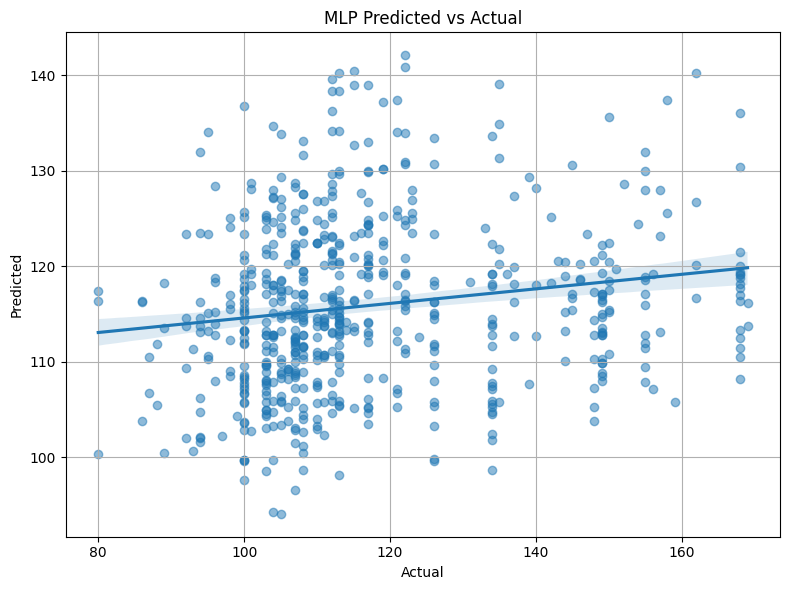

In [64]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

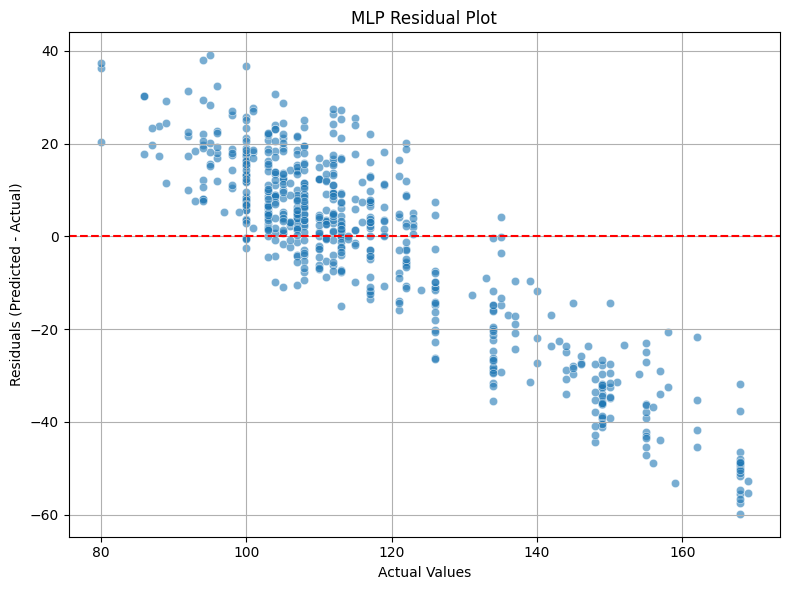

In [65]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()